## Final Plots for SIAM Paper Submission

### IMPORTS

In [1]:
import torch
import numpy as np
import GPKoopman as gpk
from datetime import datetime
import matplotlib.pyplot as plt
import math
from get_iGPK_fcn import get_iGPK
import os
from datetime import datetime

## PENDULUM ON A CART
SYSTEM_NAME == Cart_data

### Plots Submitted to IEEE ACCESS - INITIAL SUBMISSION

In [ ]:
results_sweep = torch.load(f'Figures/Journal/Cart_data_35D-20260325/AllData_Cart_data_noise-uniform_int-0.150_seed-1234_20260325.pt', weights_only=True)
results_kDMD = torch.load('Figures/Journal/kDMD_Results/Cart_data-35D-20260325/SavedDict.pt', weights_only=True)
TestErrors = {
    "iGPK":      results_sweep[0].get('ErrTest', None),
    "Poly-eDMD": results_sweep[1].get('ErrTest', None),
    "SSID-GPK":  results_sweep[3].get('ErrTest', None),
    "RBF-eDMD":  results_sweep[2].get('ErrTest', None),
    "kDMD":      results_kDMD[2].get('TestError', None),
}

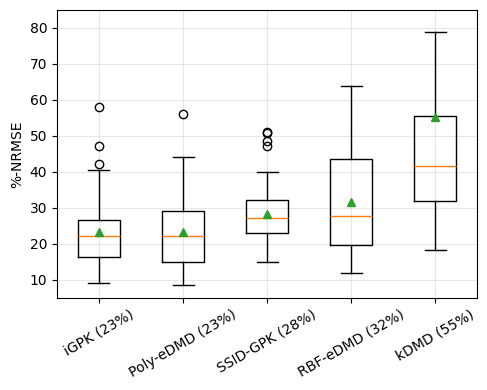

In [6]:
data, labels = [], []
for name, tensor in TestErrors.items():
    # Collapse second dimension → (19,)
    traj_mean = tensor.mean(dim=1)
    overall_mean = 100 * tensor.mean()

    data.append(100*traj_mean.detach().cpu().numpy())
    labels.append(f'{name} ({overall_mean:.0f}%)')

# Create violin plot
plt.figure(figsize=(5, 4))
plt.boxplot(data, showmeans=True, widths=0.5)

plt.xticks(range(1, len(labels) + 1), labels, rotation=30)
plt.ylabel("%-NRMSE")
# plt.title("Test Error Distribution Across Models")
plt.grid(alpha=0.3)
plt.ylim((5.,85.))

plt.tight_layout()
plt.show()
del data, labels

In [7]:
Xhat_Test = {
    "Poly-eDMD": results_sweep[1].get('test', None).get('Xhat', None),
    "RBF-eDMD":  results_sweep[2].get('test', None).get('Xhat', None),
    "kDMD":      results_kDMD[2].get('TestTraj', None),
    "SSID-GPK":  results_sweep[3].get('test', None).get('Xhat', None),
    "iGPK":      results_sweep[0].get('test', None).get('Xhat', None),
}   # each value is a tensor of shape (num_traj, num_states, num_time-steps)
Xcvhat_Test = {
    "SSID-GPK":  results_sweep[3].get('test', None).get('Xcvhat', None),
    "iGPK":      results_sweep[0].get('test', None).get('Xcvhat', None)
}   # each value is a tensor of shape (num_traj, num_states, num_states, num_time-steps)
Xhat_Test['kDMD'] = Xhat_Test['kDMD'][:, :, :100]

traj_idx = torch.argmin(TestErrors['iGPK'].mean(dim=1))
print(f'Producing plot for Test Trajectory {traj_idx}')

Producing plot for Test Trajectory 25


In [ ]:
nz = 35
data_n00 = torch.load(f'Figures/Journal/Cart_data_{nz}D-20260422/AllData_Cart_data_noise-gaussian_int-0.000_seed-1234_20260422.pt', weights_only=True)
data_u05 = torch.load(f'Figures/Journal/Cart_data_{nz}D-20260422/AllData_Cart_data_noise-uniform_int-0.050_seed-1234_20260422.pt', weights_only=True)
data_u10 = torch.load(f'Figures/Journal/Cart_data_{nz}D-20260422/AllData_Cart_data_noise-uniform_int-0.100_seed-1234_20260422.pt', weights_only=True)
data_u15 = torch.load(f'Figures/Journal/Cart_data_{nz}D-20260422/AllData_Cart_data_noise-uniform_int-0.150_seed-1234_20260422.pt', weights_only=True)
data_u20 = torch.load(f'Figures/Journal/Cart_data_{nz}D-20260422/AllData_Cart_data_noise-uniform_int-0.200_seed-1234_20260422.pt', weights_only=True)

# results_kDMD = torch.load(f'Figures/Journal/kDMD_Results/Scalar NL-{nz}D-20260401/SavedDict.pt', weights_only=True)

for i in range(4):
    name = data_n00[i].get('name', None)
    if data_n00[i].get('name', None) == 'iGPK':
        idx_iGPK = i
    elif data_n00[i].get('name', None) == 'SSID-GPK':
        idx_SSID = i
    elif data_n00[i].get('name', None) == 'Poly-eDMD':
        idx_Poly = i
    elif data_n00[i].get('name', None) == 'RBF-eDMD':
        idx_rbf = i
    else:
        print(f'ERROR: Did not find iGPK, SSID-GPK, Poly-eDMD or RBF-eDMD data records!')

TestErrors = {
    "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
    "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
    "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
    "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
    # "kDMD":      results_kDMD[2].get('TestError', None),
}
NRMSE_Test = {
    "Clean": {
        "iGPK":         data_n00[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n00[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n00[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n00[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[0].get('TestError', None),
        },
    "Uniform 5%": {
        "iGPK":         data_u05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u05[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[0].get('TestError', None),
    },
    "Uniform 10%": {
        "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[1].get('TestError', None),
    },
    "Uniform 15%": {
        "iGPK":         data_u15[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u15[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u15[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u15[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[2].get('TestError', None),
    },
    "Uniform 20%": {
        "iGPK":         data_u20[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u20[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u20[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u20[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[3].get('TestError', None),
    },
}

Xhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xhat', None),
    },
    "Uniform 15%": {
        'SSID-GPK': data_u15[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u15[idx_iGPK].get('train', None).get('Xhat', None),
    },
    "Uniform 20%": {
        'SSID-GPK': data_u20[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u20[idx_iGPK].get('train', None).get('Xhat', None),
    },
}

Xcvhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xcvhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
    "Uniform 15%": {
        'SSID-GPK': data_u15[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u15[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
    "Uniform 20%": {
        'SSID-GPK': data_u20[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u20[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
}

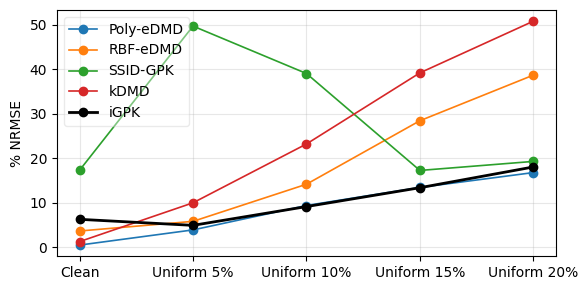

In [23]:
NRMSE_Test_bymdl = {
    "Poly-eDMD":    [100.0*float(data['Poly-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "RBF-eDMD":     [100.0*float(data['RBF-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "SSID-GPK":     [100.0*float(data['SSID-GPK'].median()) for _, data in NRMSE_Test.items()],
    "kDMD":         [100.0*float(data['kDMD'].median()) for _, data in NRMSE_Test.items()],
    "iGPK":         [100.0*float(data['iGPK'].median()) for _, data in NRMSE_Test.items()],
    }
NRMSE_Test_bymdl['kDMD'][0] = 1.31
noise_labels = NRMSE_Test.keys()
levels = [0, 5, 10, 15, 20]
plt.figure(figsize=(6,3))
for model, mean_err in NRMSE_Test_bymdl.items():
    if model == 'iGPK':
        plt.plot(levels, mean_err, marker="o", linewidth=2, label=model, color='black')
    else:
        plt.plot(levels, mean_err, marker="o", linewidth=1.2, label=model)

plt.xticks(levels, noise_labels, rotation=0)
# plt.xlabel("Noise level")
plt.ylabel("% NRMSE")
# plt.xlim([-1, 16])
# plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(framealpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Cart_data", 0.6, 0.4, clip=100)

SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)
SimData = gpk.add_noise(SimData_clean, noise_type="uniform",
    intensity=0.15, seed=100)

GT_test = SimData[nTrain:nTrain+nTest, :, :N-1]  # (nTest, n, N)
XhatTest, XhatTest_ssid = Xhat_Test['iGPK'], Xhat_Test['SSID-GPK']
XcvhatTest, XcvhatTest_ssid = Xcvhat_Test['iGPK'], Xcvhat_Test['SSID-GPK']

nlpd_traj_test_igpk = _nlpd_per_traj(
    XhatTest[:, :, :N-1],       XcvhatTest[:, :, :, :N-1],       GT_test).detach().cpu()
# nlpd_traj_train_ssid = _nlpd_per_traj(XhatTrain_ssid[:,:,:N-1], XcvhatTrain_ssid[:,:,:,:N-1], GT_train).detach().cpu()
nlpd_traj_test_ssid = _nlpd_per_traj(
    XhatTest_ssid[:, :, :N-1],  XcvhatTest_ssid[:, :, :, :N-1],  GT_test).detach().cpu()

# Print summary
def _ms(x):
    return float(x.mean()), float(x.std(unbiased=False))
# m, s = _ms(nlpd_traj_train_igpk);  print(f"Train NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
# m, s = _ms(nlpd_traj_train_ssid);  print(f"Train NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")
m, s = _ms(nlpd_traj_test_igpk)
print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")
m, s = _ms(nlpd_traj_test_ssid)
print(f"Test  NLPD SSID-GPK: mean={m:.4f}, std={s:.4f}")

Test  NLPD iGPK:     mean=5.9382, std=0.6769
Test  NLPD SSID-GPK: mean=14721.5483, std=20721.1559


### Plots from Fully Refactored Codebase

In [ ]:
nz = 35
datestamp = '20260626'
seed = '100'
direc = 'Figures/ieee-access'
data_n00 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-gaussian_int-0.000_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u05 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-uniform_int-0.050_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u10 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-uniform_int-0.100_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u15 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-uniform_int-0.150_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u20 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-uniform_int-0.200_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n05 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-gaussian_int-0.050_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n10 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-gaussian_int-0.100_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n15 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-gaussian_int-0.150_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n20 = torch.load(f'{direc}/Cart_data_{nz}D-{datestamp}/AllData_Cart_data_noise-gaussian_int-0.200_seed-{seed}_{datestamp}.pt', weights_only=True)

# results_kDMD = torch.load(f'Figures/Journal/kDMD_Results/Scalar NL-{nz}D-20260401/SavedDict.pt', weights_only=True)
results_kDMD = torch.load('Figures/ieee-access/kDMD_Results/Cart_data-35D-20260325/SavedDict.pt', weights_only=True)
results_kDMD_n = torch.load('Figures/ieee-access/kDMD_Results/Cart_data-35D/SavedDict.pt', weights_only=True)
for i in range(4):
    name = data_n00[i].get('name', None)
    if data_n00[i].get('name', None) == 'iGPK':
        idx_iGPK = i
    elif data_n00[i].get('name', None) == 'SSID-GPK':
        idx_SSID = i
    elif data_n00[i].get('name', None) == 'Poly-eDMD':
        idx_Poly = i
    elif data_n00[i].get('name', None) == 'RBF-eDMD':
        idx_rbf = i
    else:
        print(f'ERROR: Did not find iGPK, SSID-GPK, Poly-eDMD or RBF-eDMD data records!')

NRMSE_Test = {
    "Gaussian 20%": {
        "iGPK":         data_n20[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n20[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n20[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n20[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD_n[4].get('TestError', None),
    },
    "Gaussian 15%": {
        "iGPK":         data_n15[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n15[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n15[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n15[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD_n[3].get('TestError', None),
    },
    "Gaussian 10%": {
        "iGPK":         data_n10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n10[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD_n[2].get('TestError', None),
    },
    "Gaussian 5%": {
        "iGPK":         data_n05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n05[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD_n[1].get('TestError', None),
    },
    "Clean": {
        "iGPK":         data_n00[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n00[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n00[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n00[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD_n[0].get('TestError', None),
        },
    "Uniform 5%": {
        "iGPK":         data_u05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u05[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[0].get('TestError', None),
    },
    "Uniform 10%": {
        "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[1].get('TestError', None),
    },
    "Uniform 15%": {
        "iGPK":         data_u15[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u15[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u15[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u15[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[2].get('TestError', None),
    },
    "Uniform 20%": {
        "iGPK":         data_u20[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u20[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u20[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u20[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[3].get('TestError', None),
    },
}

Xhat_Test = {
    "Gaussian 20%": {
        'SSID-GPK': data_n20[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n20[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Gaussian 15%": {
        'SSID-GPK': data_n15[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n15[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Gaussian 10%": {
        'SSID-GPK': data_n10[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n10[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Gaussian 5%": {
        'SSID-GPK': data_n05[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n05[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n00[idx_iGPK].get('test', None).get('Xhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u05[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u10[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Uniform 15%": {
        'SSID-GPK': data_u15[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u15[idx_iGPK].get('test', None).get('Xhat', None),
        'Poly-eDMD': data_u15[idx_Poly].get('test', None).get('Xhat', None),
        'RBF-eDMD': data_u15[idx_rbf].get('test', None).get('Xhat', None),
        # 'Poly-eDMD': data_u15[idx].get('test', None).get('Xhat', None),
    },
    "Uniform 20%": {
        'SSID-GPK': data_u20[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u20[idx_iGPK].get('test', None).get('Xhat', None),
    },
}

Xcvhat_Test = {
    "Gaussian 20%": {
        'SSID-GPK': data_n20[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n20[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Gaussian 15%": {
        'SSID-GPK': data_n15[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n15[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Gaussian 10%": {
        'SSID-GPK': data_n10[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n10[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Gaussian 5%": {
        'SSID-GPK': data_n05[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n05[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n00[idx_iGPK].get('test', None).get('Xcvhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u05[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u10[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Uniform 15%": {
        'SSID-GPK': data_u15[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u15[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Uniform 20%": {
        'SSID-GPK': data_u20[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u20[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
}

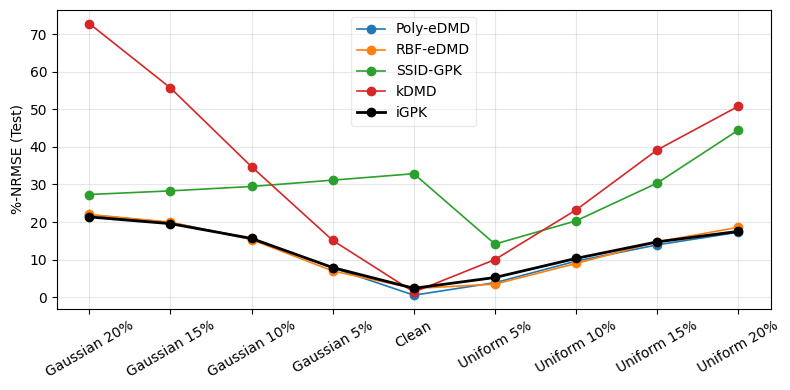

In [5]:
NRMSE_Test_bymdl = {
    "Poly-eDMD":    [100.0*float(data['Poly-eDMD'].mean()) for _, data in NRMSE_Test.items()],
    "RBF-eDMD":     [100.0*float(data['RBF-eDMD'].mean()) for _, data in NRMSE_Test.items()],
    "SSID-GPK":     [100.0*float(data['SSID-GPK'].mean()) for _, data in NRMSE_Test.items()],
    "kDMD":         [100.0*float(data['kDMD'].mean()) for _, data in NRMSE_Test.items()],
    "iGPK":         [100.0*float(data['iGPK'].mean()) for _, data in NRMSE_Test.items()],
    }

NRMSE_Test_bymdl_median = {
    "Poly-eDMD":    [100.0*float(data['Poly-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "RBF-eDMD":     [100.0*float(data['RBF-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "SSID-GPK":     [100.0*float(data['SSID-GPK'].median()) for _, data in NRMSE_Test.items()],
    "kDMD":         [100.0*float(data['kDMD'].median()) for _, data in NRMSE_Test.items()],
    "iGPK":         [100.0*float(data['iGPK'].median()) for _, data in NRMSE_Test.items()],
    }

noise_labels = NRMSE_Test.keys()
levels = [i for i in range(len(NRMSE_Test))]
plt.figure(figsize=(8.05,4))
for model, mean_err in NRMSE_Test_bymdl_median.items():
    if model == 'iGPK':
        plt.plot(levels, mean_err, marker="o", linewidth=2, label=model, color='black')
    else:
        plt.plot(levels, mean_err, marker="o", linewidth=1.2, label=model)

plt.xticks(levels, noise_labels, rotation=30)
# plt.xlabel("Noise level")
plt.ylabel("%-NRMSE (Test)")
# plt.xlim([-1, 16])
# plt.yscale('symlog')
# plt.ylim(0.1, 80)
plt.grid(True, alpha=0.3)
plt.legend(framealpha=0.4)
plt.tight_layout()
plt.show()

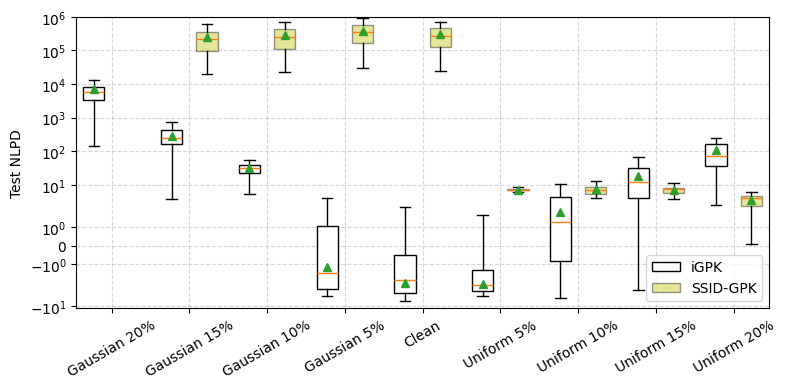

In [12]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Cart_data", 0.6, 0.4, clip=None)
SimData_raw = torch.flip(SimData_raw, dims=[0])
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTest, nTrain, N)

NLPD_Test = {}

def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1   # inter-quartile range
    LB = q1 - 1.5 * iqr
    UB = q3 + 1.5 * iqr

    return data[(data >= LB) & (data <= UB)]    # filtered data


for label, _ in Xhat_Test.items():
    GT_test = SimData_clean[:nTest, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = gpk.nlpd_per_traj(
        XhatTest[:nTest, :, :N-1],       XcvhatTest[:nTest, :, :, :N-1], GT_test[:nTest, :, :]).detach().cpu()
    nlpd_traj_test_ssid = gpk.nlpd_per_traj(
        XhatTest_ssid[:nTest, :, :N-1],  XcvhatTest_ssid[:nTest, :, :, :N-1],  GT_test[:nTest, :, :]).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

labels = list(NLPD_Test.keys())

data, positions, xticks = [], [], []

pos = 1
for label in labels:
    igpk = NLPD_Test[label]['iGPK'].numpy()
    ssid = NLPD_Test[label]['SSID-GPK'].numpy()
    igpk = remove_outliers(igpk)
    ssid = remove_outliers(ssid)

    # Add both models for this label
    data.extend([igpk, ssid])
    positions.extend([pos, pos + 1])

    # Center tick between the two boxes
    xticks.append(pos + 0.5)

    pos += 2.2  # spacing between groups

fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showmeans=True, showfliers=False)

# Optional: color coding
for i, patch in enumerate(bp['boxes']):
    if i % 2 == 0:
        patch.set_facecolor('w')   # iGPK
    else:
        patch.set_facecolor('y') # SSID-GPK
        patch.set_alpha(0.4)

# X-axis formatting
ax.set_xticks(xticks)
ax.set_xticklabels(labels, rotation=30)
ax.set_ylabel("Test NLPD")
ax.set_yscale('symlog')
ax.set_ylim((-11, 1e6))
xmin, xmax = ax.get_xlim()
# ax.set_xlim((xmin, xmax*1.05))

# Legend
ax.legend([bp["boxes"][0], bp["boxes"][1]],
            ["iGPK", "SSID-GPK"],
            loc="lower right")

# --- After creating the boxplot ---
# for i, (d, x) in enumerate(zip(data, positions)):
#     mean_val = np.mean(d)

#     ax.text(
#         x+0.35, mean_val ,
#         f"{mean_val:.1e}",
#         ha='left', va='center',
#         fontsize=8
#     )

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# computational time from console output
# G00 49.8
# G05 129.78
# G10 43.68
# G15 55.71
# G20 43.98
# U05 42.26
# U10 262.82
# U15 42.17
# U20 266.03
# MEAN = 104.025 seconds

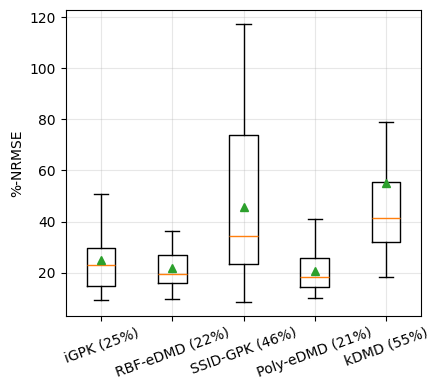

In [4]:
errs = NRMSE_Test['Uniform 15%']
data, labels = [], []
for name, tensor in errs.items():
    # Collapse second dimension → (19,)
    traj_mean = tensor.mean(dim=1)
    overall_mean = 100 * tensor.mean()

    data.append(100*traj_mean.detach().cpu().numpy())
    labels.append(f'{name} ({overall_mean:.0f}%)')

# Create violin plot
plt.figure(figsize=(4.5, 4))
plt.boxplot(data, showmeans=True, widths=0.4, showfliers=False)

plt.xticks(range(1, len(labels) + 1), labels, rotation=20)
plt.ylabel("%-NRMSE")
# plt.title("Test Error Distribution Across Models")
plt.grid(alpha=0.3)
# plt.ylim((5.,150.))

plt.tight_layout()
plt.show()
del data, labels

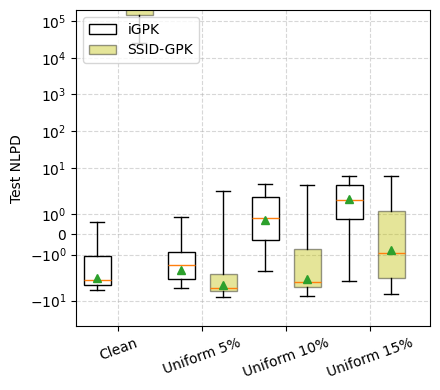

In [20]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Cart_data", 0.6, 0.4, clip=None)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)

NLPD_Test = {}

def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1   # inter-quartile range
    LB = q1 - 1.5 * iqr
    UB = q3 + 1.5 * iqr

    return data[(data >= LB) & (data <= UB)]    # filtered data

labels = ['Clean', 'Uniform 5%', 'Uniform 10%', 'Uniform 15%']

for label in labels:
    GT_test = SimData_clean[nTrain:nTrain+nTest+1, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = gpk.nlpd_per_traj(
        XhatTest[:nTest, :, :N-1],       XcvhatTest[:nTest, :, :, :N-1], GT_test[:nTest, :, :]).detach().cpu()
    nlpd_traj_test_ssid = gpk.nlpd_per_traj(
        XhatTest_ssid[:nTest, :, :N-1],  XcvhatTest_ssid[:nTest, :, :, :N-1],  GT_test[:nTest, :, :]).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

labels = list(NLPD_Test.keys())

data, positions, xticks = [], [], []

pos = 1
for label in labels:
    igpk = NLPD_Test[label]['iGPK'].numpy()
    ssid = NLPD_Test[label]['SSID-GPK'].numpy()
    igpk = remove_outliers(igpk)
    ssid = remove_outliers(ssid)

    # Add both models for this label
    data.extend([igpk, ssid])
    positions.extend([pos, pos + 1])

    # Center tick between the two boxes
    xticks.append(pos + 0.5)

    pos += 2.0  # spacing between groups

fig, ax = plt.subplots(figsize=(4.5, 4))

bp = ax.boxplot(data, positions=positions, widths=0.65, patch_artist=True, showmeans=True, showfliers=False)

# Optional: color coding
for i, patch in enumerate(bp['boxes']):
    if i % 2 == 0:
        patch.set_facecolor('w')   # iGPK
    else:
        patch.set_facecolor('y') # SSID-GPK
        patch.set_alpha(0.4)

# X-axis formatting
ax.set_xticks(xticks)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("Test NLPD")
ax.set_yscale('symlog')
ax.set_ylim((-5e1, 2e5))
xmin, xmax = ax.get_xlim()
ax.set_xlim((xmin, xmax*1.05))

# Legend
ax.legend([bp["boxes"][0], bp["boxes"][1]],
            ["iGPK", "SSID-GPK"],
            loc="upper left")

# --- After creating the boxplot ---
# for i, (d, x) in enumerate(zip(data, positions)):
#     mean_val = np.mean(d)
#     ax.text(
#         x+0.35, mean_val ,
#         f"{mean_val:.1e}",
#         ha='left', va='center',
#         fontsize=8
#     )

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

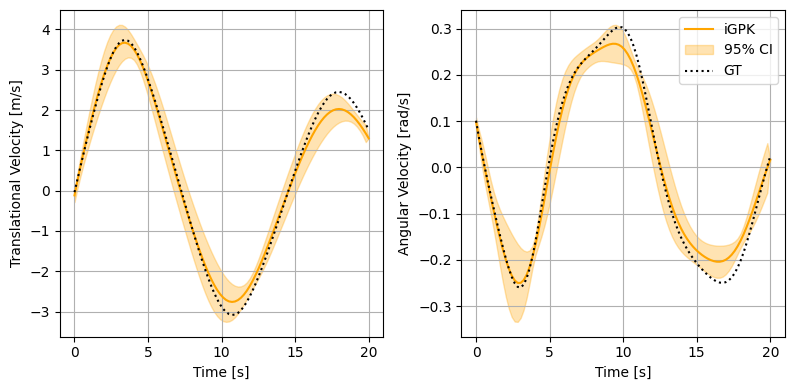

In [49]:
# Trajectory Plot for x_dim = 1 and 3
noise_case = 'Uniform 10%'
traj = Xhat_Test[noise_case]
trajCV = Xcvhat_Test[noise_case]
_, idx = torch.min(NRMSE_Test[noise_case]['iGPK'].mean(dim=1), dim=-1, keepdim=False)
idx = idx.item()
time = torch.linspace(0, 20., steps=Xhat_Test[noise_case]['iGPK'].shape[2])

fig, axs = plt.subplots(1, 2, figsize=(8.05, 4), sharex=True)
for ax, x_dim in zip(axs, [1, 3]):
    for mdl_idx, (mdl, data) in enumerate(traj.items()):
        if mdl == 'SSID-GPK':
            continue
        ax.plot(time, mu_vec[x_dim] + (std_vec[x_dim] * data[idx, x_dim]), label=mdl, color='orange')
        ax.fill_between(
            time,
            mu_vec[x_dim] + std_vec[x_dim] * (data[idx, x_dim] + 2 * (trajCV[mdl][idx, x_dim, x_dim, :].abs().sqrt())),
            mu_vec[x_dim] + std_vec[x_dim] * (data[idx, x_dim] - 2 * (trajCV[mdl][idx, x_dim, x_dim, :].abs().sqrt())),
            alpha=0.3,
            color='orange',
            label='95% CI',
        )
        # nrmse_pct = 100 * NRMSE_Test[noise_case][mdl][idx, x_dim].item()
        # ax.text(
        #     0.72,
        #     0.04 * mdl_idx,
        #     f"NRMSE: {nrmse_pct:.1f}%",
        #     transform=ax.transAxes,
        #     va='bottom',
        #     fontsize=8,
        # )

    ax.plot(
        time,
        mu_vec[x_dim] + std_vec[x_dim] * (SimData_clean[idx, x_dim, :N]),
        linestyle=':',
        label='GT',
        color='black',
    )
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Translational Velocity [m/s]' if x_dim == 1 else 'Angular Velocity [rad/s]')
    ax.grid(True)

axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

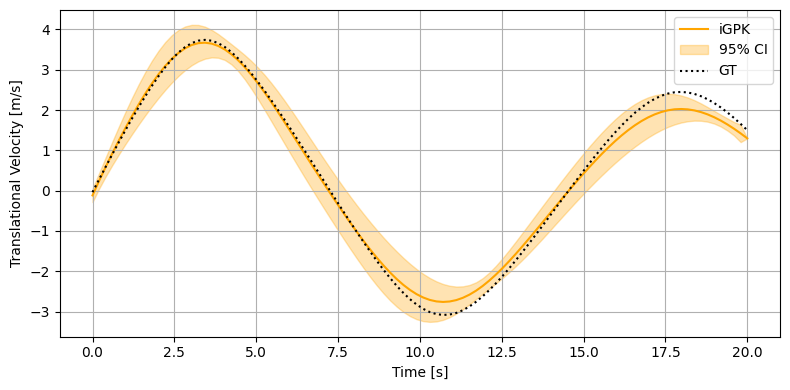

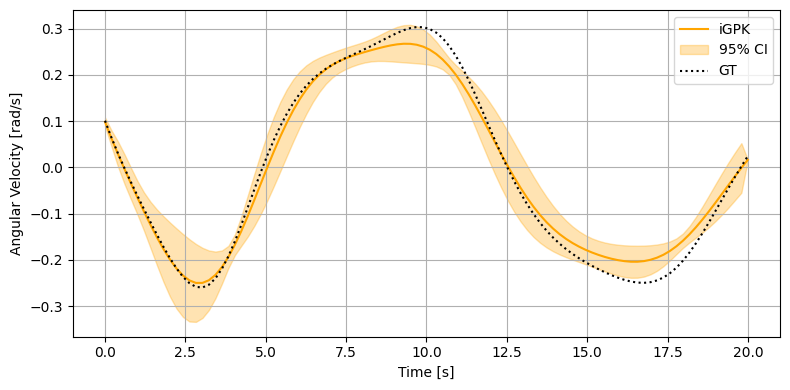

In [15]:
# Trajectory Plot for x_dim = 1 and 3
noise_case = 'Uniform 10%'
traj = Xhat_Test[noise_case]
trajCV = Xcvhat_Test[noise_case]
_, idx = torch.min(NRMSE_Test[noise_case]['iGPK'].mean(dim=1), dim=-1, keepdim=False)
idx = idx.item()
time = torch.linspace(0, 20., steps=Xhat_Test[noise_case]['iGPK'].shape[2])

for x_dim in [1, 3]:
    plt.figure(figsize=(8, 4))
    for mdl_idx, (mdl, data) in enumerate(traj.items()):
        if mdl == 'SSID-GPK':
            continue
        plt.plot(time, mu_vec[x_dim] + (std_vec[x_dim] * data[idx, x_dim]), label=mdl, color='orange')
        plt.fill_between(
            time,
            mu_vec[x_dim] + std_vec[x_dim] * (data[idx, x_dim] + 2 * (trajCV[mdl][idx, x_dim, x_dim, :].abs().sqrt())),
            mu_vec[x_dim] + std_vec[x_dim] * (data[idx, x_dim] - 2 * (trajCV[mdl][idx, x_dim, x_dim, :].abs().sqrt())),
            alpha=0.3,
            color='orange',
            label='95% CI',
        )
        # nrmse_pct = 100 * NRMSE_Test[noise_case][mdl][idx, x_dim].item()
        # plt.text(
        #     0.72,
        #     0.04 * mdl_idx,
        #     f"NRMSE: {nrmse_pct:.1f}%",
        #     transform=plt.gca().transAxes,
        #     va='bottom',
        #     fontsize=8,
        # )

    plt.plot(
        time,
        mu_vec[x_dim] + std_vec[x_dim] * (SimData_clean[idx, x_dim, :N]),
        linestyle=':',
        label='GT',
        color='black',
    )
    plt.xlabel('Time [s]')
    plt.ylabel('Translational Velocity [m/s]' if x_dim == 1 else 'Angular Velocity [rad/s]')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

### Trajectory Plot

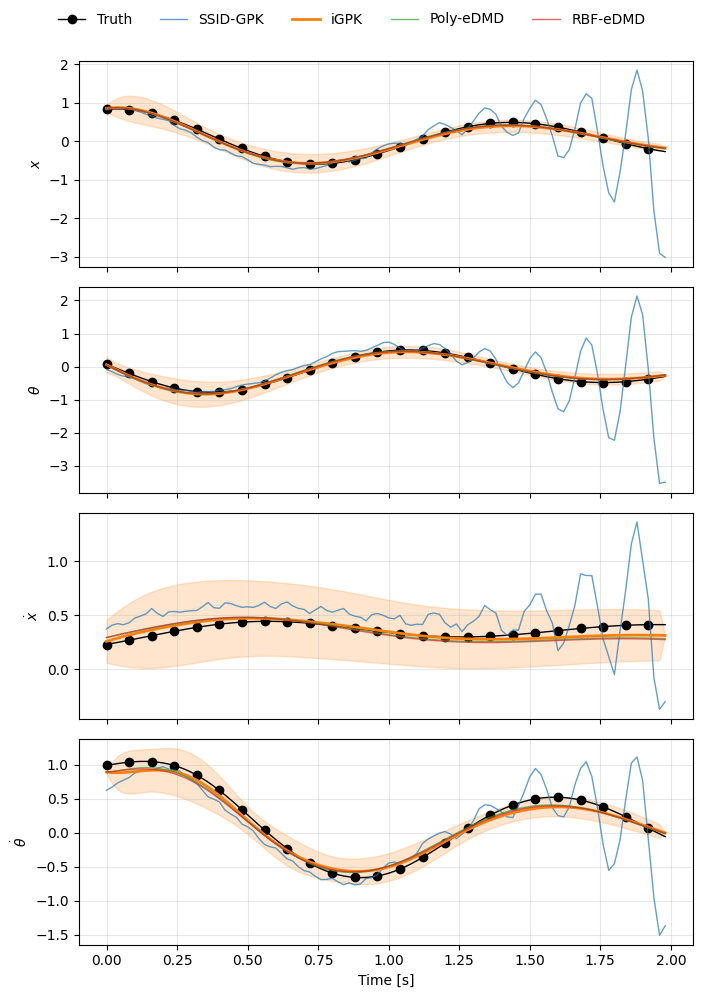

In [22]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Cart_data", 0.6, 0.4, clip=None)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTest, nTrain, N)
noise_case = 'Uniform 15%'
_, idx = torch.min(NRMSE_Test[noise_case]['iGPK'].mean(dim=1), dim=-1, keepdim=False)
traj_idx = idx.item()
# State labels (shown on y-axis for each stacked subplot)
state_labels = [r'$x$', r'$\theta$', r'$\dot{x}$', r'$\dot{\theta}$']

# Get time length from first available model
first_model = next(v for v in Xhat_Test.values() if v is not None)
T = Xhat_Test[noise_case]['iGPK'].shape[2]
t = np.arange(T)
t = t * 0.02

fig, axes = plt.subplots(4, 1, figsize=(7, 10), sharex=True)
for i in range(4):
    line, = axes[i].plot(t, SimData_clean[traj_idx, i, :N], label='Truth', alpha=1, linewidth=1, color='black', marker='o', markevery=4)
    for model_name, Xhat in Xhat_Test[noise_case].items():
        # (num_states, num_time_steps)
        Xtraj = Xhat[traj_idx].detach().cpu().numpy()

        if model_name == 'iGPK':
            line, = axes[i].plot(t, Xtraj[i], label=model_name, alpha=1, linewidth=2)
        else:
            line, = axes[i].plot(t, Xtraj[i], label=model_name, alpha=0.7, linewidth=1)
        # axes[i].set_yscale('symlog')
        # axes[i].set_xlim((0, 1.9))

        # Add ±1 sigma shaded band if covariance exists for this model
        # if model_name in Xcvhat_Test[noise_case]:
        if model_name == 'iGPK':
            # Variance of state i over time is diagonal entry [i,i,:]
            var_i = Xcvhat_Test[noise_case][model_name][traj_idx, i, i, :].detach().cpu().numpy()
            var_i = np.abs(var_i)  # numerical safety
            sigma_i = np.sqrt(var_i)

            axes[i].fill_between(
                t,
                Xtraj[i] - 1*sigma_i,
                Xtraj[i] + 1*sigma_i,
                color=line.get_color(),
                alpha=0.2
            )

# Formatting
for i, ax in enumerate(axes):
    ax.set_ylabel(state_labels[i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Scalar NL

### Load and Reshape Data

In [ ]:
nz = 5
data_n00 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.000_seed-100_20260401.pt', weights_only=True)
data_n05 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.050_seed-100_20260401.pt', weights_only=True)
data_n10 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-gaussian_int-0.100_seed-100_20260401.pt', weights_only=True)
data_u05 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-uniform_int-0.050_seed-100_20260401.pt', weights_only=True)
data_u10 = torch.load(f'Figures/Journal/Scalar NL_{nz}D-20260401/AllData_Scalar_NL_noise-uniform_int-0.100_seed-100_20260401.pt', weights_only=True)

results_kDMD = torch.load(f'Figures/ieee-access/kDMD_Results/Scalar NL-{nz}D-20260401/SavedDict.pt', weights_only=True)

for i in range(4):
    name = data_n00[i].get('name', None)
    if data_n00[i].get('name', None) == 'iGPK':
        idx_iGPK = i
    elif data_n00[i].get('name', None) == 'SSID-GPK':
        idx_SSID = i
    elif data_n00[i].get('name', None) == 'Poly-eDMD':
        idx_Poly = i
    elif data_n00[i].get('name', None) == 'RBF-eDMD':
        idx_rbf = i
    else:
        print(f'ERROR: Did not find iGPK, SSID-GPK, Poly-eDMD or RBF-eDMD data records!')

TestErrors = {
    "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
    "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
    "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
    "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
    # "kDMD":      results_kDMD[2].get('TestError', None),
}
NRMSE_Test = {
    "Clean": {
        "iGPK":         data_n00[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n00[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n00[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n00[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[0].get('TestError', None),
        },
    "Uniform 5%": {
        "iGPK":         data_u05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u05[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[3].get('TestError', None),
    },
    "Uniform 10%": {
        "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
        "kDMD":         results_kDMD[4].get('TestError', None),
    },
}

Xhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xhat', None),
    },
}

Xcvhat_Test = {
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_n00[idx_iGPK].get('train', None).get('Xcvhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u05[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('train', None).get('Xcvhat', None),
        'iGPK': data_u10[idx_iGPK].get('train', None).get('Xcvhat', None),
    },
}

### Test-NRMSE Scalar NL

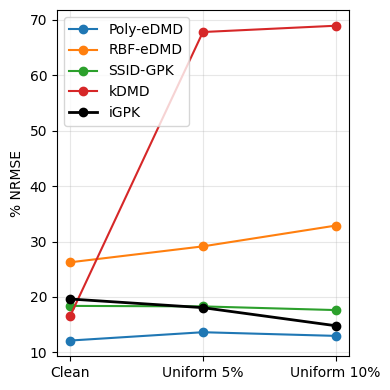

In [25]:
NRMSE_Test_bymdl = {
    "Poly-eDMD":    [100.0*float(data['Poly-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "RBF-eDMD":     [100.0*float(data['RBF-eDMD'].median()) for _, data in NRMSE_Test.items()],
    "SSID-GPK":     [100.0*float(data['SSID-GPK'].median()) for _, data in NRMSE_Test.items()],
    "kDMD":         [100.0*float(data['kDMD'].median()) for _, data in NRMSE_Test.items()],
    "iGPK":         [100.0*float(data['iGPK'].median()) for _, data in NRMSE_Test.items()],
    }
noise_labels = NRMSE_Test.keys()
plt.figure(figsize=(4,4))
for model, mean_err in NRMSE_Test_bymdl.items():
    if model == 'iGPK':
        plt.plot([0, 5, 10], mean_err, marker="o", linewidth=2, label=model, color='black')
    else:
        plt.plot([0, 5, 10], mean_err, marker="o", linewidth=1.5, label=model)

plt.xticks([0, 5, 10], noise_labels)
# plt.xlabel("Noise level")
plt.ylabel("% NRMSE")
# plt.yscale('symlog')
# plt.yticks([10.,20.,30.])
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

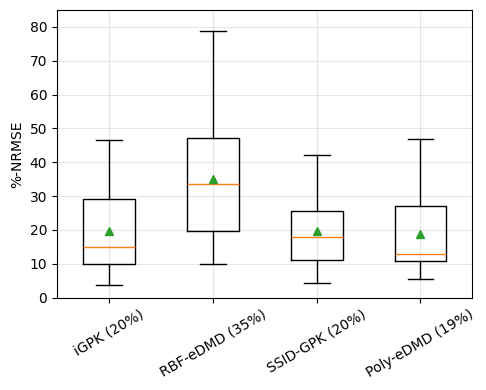

In [23]:
data, labels = [], []
for name, tensor in TestErrors.items():
    # Collapse second dimension → (19,)
    traj_mean = tensor.mean(dim=1)
    overall_mean = 100 * tensor.mean()

    data.append(100*traj_mean.detach().cpu().numpy())
    labels.append(f'{name} ({overall_mean:.0f}%)')

# Create violin plot
plt.figure(figsize=(5, 4))
plt.boxplot(data, showmeans=True, widths=0.5)

plt.xticks(range(1, len(labels) + 1), labels, rotation=30)
plt.ylabel("%-NRMSE")
# plt.title("Test Error Distribution Across Models")
plt.grid(alpha=0.3)
plt.ylim((0.,85.))

plt.tight_layout()
plt.show()
del data, labels

### NLPD - Scalar NL

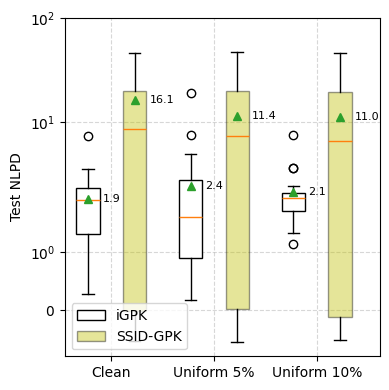

In [ ]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Scalar NL", 0.6, 0.4, clip=50)
SimData_raw = torch.flip(SimData_raw, dims=[0])
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTest, nTrain, N)

intensity = -0.10
NLPD_Test = {}

for label, _ in Xhat_Test.items():
    if intensity <= 0.0:
        SimData = gpk.add_noise(SimData_clean, noise_type="gaussian",
            intensity=abs(intensity), seed=100)
    else:
        SimData = gpk.add_noise(SimData_clean, noise_type="uniform",
            intensity=intensity, seed=100)

    GT_test = SimData_clean[nTrain:nTrain+nTest+1, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = gpk.nlpd_per_traj(
        XhatTest[:nTest, :, :N-1],       XcvhatTest[:nTest, :, :, :N-1], GT_test[:nTest, :, :]).detach().cpu()
    nlpd_traj_test_ssid = gpk.nlpd_per_traj(
        XhatTest_ssid[:nTest, :, :N-1],  XcvhatTest_ssid[:nTest, :, :, :N-1],  GT_test[:nTest, :, :]).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

    # Print summary
    intensity += 0.05

labels = list(NLPD_Test.keys())

data, positions, xticks = [], [], []

pos = 1
for label in labels:
    igpk = NLPD_Test[label]['iGPK'].numpy()
    ssid = NLPD_Test[label]['SSID-GPK'].numpy()

    # Add both models for this label
    data.extend([igpk, ssid])
    positions.extend([pos, pos + 1])

    # Center tick between the two boxes
    xticks.append(pos + 0.5)

    pos += 2.2  # spacing between groups

fig, ax = plt.subplots(figsize=(4, 4))

bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showmeans=True)

# Optional: color coding
for i, patch in enumerate(bp['boxes']):
    if i % 2 == 0:
        patch.set_facecolor('w')   # iGPK
    else:
        patch.set_facecolor('y') # SSID-GPK
        patch.set_alpha(0.4)

# X-axis formatting
ax.set_xticks(xticks)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Test NLPD")
ax.set_yscale('symlog')
ax.set_ylim((-0.8, 100))
xmin, xmax = ax.get_xlim()
ax.set_xlim((xmin, xmax*1.05))

# Legend
ax.legend([bp["boxes"][0], bp["boxes"][1]],
            ["iGPK", "SSID-GPK"],
            loc="lower left")

# --- After creating the boxplot ---
for i, (d, x) in enumerate(zip(data, positions)):
    mean_val = np.mean(d)

    ax.text(
        x+0.32, mean_val ,
        f"{mean_val:.1f}",
        ha='left', va='center',
        fontsize=8
    )

ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

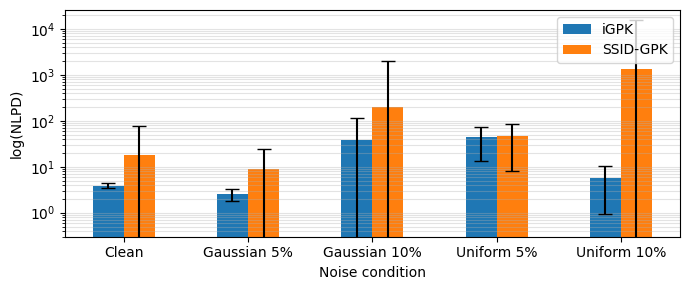

In [ ]:
# -------------------------
# Data from the LaTeX table
# -------------------------
conditions = ["Clean", "Gaussian 5%",
              "Gaussian 10%", "Uniform 5%", "Uniform 10%"]
x = np.arange(len(conditions))  # categorical axis
data = {
    "iGPK": {
        "mean": [3.89, 2.58, 37.81, 43.5, 5.65],
        "std":  [0.45, 0.74, 76.41, 29.9, 4.7],
    },
    "SSID-GPK": {
        "mean": [18.13, 8.73, 204.13, 46.64, 1373.4],
        "std":  [58.9, 15.21, 1806.5, 38.41, 14491.6],
    },
}

# -------------------------
# Plot (landscape + log y)
# -------------------------
plt.figure(figsize=(7, 3))  # landscape aspect ratio

bar_width = 0.25
offsets = [-bar_width / 2, bar_width / 2]

for (model, stats), dx in zip(data.items(), offsets):
    mean = np.array(stats["mean"], dtype=float)
    std = np.array(stats["std"], dtype=float)

    plt.bar(
        x + dx, mean, bar_width,
        yerr=std, capsize=5,
        label=model
    )

plt.xticks(x, conditions)
plt.xlabel("Noise condition")
plt.ylabel("log(NLPD)")
# plt.title("NLPD Comparison (mean ± 1 std)")
plt.yscale("log")

# Prevent pathological lower bounds in log-space
plt.ylim(bottom=0.3)

plt.grid(True, which="both", axis="y", alpha=0.35)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Inhibited Predator-Prey

In [54]:
nz = 10
datestamp = '20260629'
seed = '100'
system = 'Inhibited_Predator-Prey'
system_dir = 'Inhibited Predator-Prey'
directory = 'ieee-access'
data_u05 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-uniform_int-0.050_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u10 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-uniform_int-0.100_seed-{seed}_{datestamp}.pt', weights_only=True)
# data_u15 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-uniform_int-0.150_seed-{seed}_{datestamp}.pt', weights_only=True)
data_u20 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-uniform_int-0.200_seed-{seed}_{datestamp}.pt', weights_only=True)
datestamp = '20260629'
data_n00 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-gaussian_int-0.000_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n05 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-gaussian_int-0.050_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n10 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-gaussian_int-0.100_seed-{seed}_{datestamp}.pt', weights_only=True)
# data_n15 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-gaussian_int-0.150_seed-{seed}_{datestamp}.pt', weights_only=True)
data_n20 = torch.load(f'Figures/{directory}/{system_dir}_{nz}D-{datestamp}/AllData_{system}_noise-gaussian_int-0.200_seed-{seed}_{datestamp}.pt', weights_only=True)

# results_kDMD = torch.load(f'Figures/Journal/kDMD_Results/Scalar NL-{nz}D-20260401/SavedDict.pt', weights_only=True)
# results_kDMD = torch.load('Figures/Journal/kDMD_Results/Cart_data-35D-20260325/SavedDict.pt', weights_only=True)
# results_kDMD_n = torch.load('Figures/Journal/kDMD_Results/Cart_data-35D/SavedDict.pt', weights_only=True)
for i in range(4):
    name = data_n00[i].get('name', None)
    if data_n00[i].get('name', None) == 'iGPK':
        idx_iGPK = i
    elif data_n00[i].get('name', None) == 'SSID-GPK':
        idx_SSID = i
    elif data_n00[i].get('name', None) == 'Poly-eDMD':
        idx_Poly = i
    elif data_n00[i].get('name', None) == 'RBF-eDMD':
        idx_rbf = i
    else:
        print(f'ERROR: Did not find iGPK, SSID-GPK, Poly-eDMD or RBF-eDMD data records!')

NRMSE_Test = {
    "Gaussian 20%": {
        "iGPK":         data_n20[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n20[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n20[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n20[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD_n[4].get('TestError', None),
    },
    # "Gaussian 15%": {
    #     "iGPK":         data_n15[idx_iGPK].get('ErrTest', None),
    #     "RBF-eDMD":     data_n15[idx_rbf].get('ErrTest', None),
    #     "SSID-GPK":     data_n15[idx_SSID].get('ErrTest', None),
    #     "Poly-eDMD":    data_n15[idx_Poly].get('ErrTest', None),
    #     # "kDMD":         results_kDMD_n[3].get('TestError', None),
    # },
    "Gaussian 10%": {
        "iGPK":         data_n10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n10[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD_n[2].get('TestError', None),
    },
    "Gaussian 5%": {
        "iGPK":         data_n05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n05[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD_n[1].get('TestError', None),
    },
    "Clean": {
        "iGPK":         data_n00[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_n00[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_n00[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_n00[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD_n[0].get('TestError', None),
        },
    "Uniform 5%": {
        "iGPK":         data_u05[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u05[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u05[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u05[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD[0].get('TestError', None),
    },
    "Uniform 10%": {
        "iGPK":         data_u10[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u10[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u10[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u10[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD[1].get('TestError', None),
    },
    # "Uniform 15%": {
    #     "iGPK":         data_u15[idx_iGPK].get('ErrTest', None),
    #     "RBF-eDMD":     data_u15[idx_rbf].get('ErrTest', None),
    #     "SSID-GPK":     data_u15[idx_SSID].get('ErrTest', None),
    #     "Poly-eDMD":    data_u15[idx_Poly].get('ErrTest', None),
    #     # "kDMD":         results_kDMD[2].get('TestError', None),
    # },
    "Uniform 20%": {
        "iGPK":         data_u20[idx_iGPK].get('ErrTest', None),
        "RBF-eDMD":     data_u20[idx_rbf].get('ErrTest', None),
        "SSID-GPK":     data_u20[idx_SSID].get('ErrTest', None),
        "Poly-eDMD":    data_u20[idx_Poly].get('ErrTest', None),
        # "kDMD":         results_kDMD[3].get('TestError', None),
    },
}

Xhat_Test = {
    # "Gaussian 20%": {
    #     'SSID-GPK': data_n20[idx_SSID].get('test', None).get('Xhat', None),
    #     'iGPK': data_n20[idx_iGPK].get('test', None).get('Xhat', None),
    # },
    # # "Gaussian 15%": {
    # #     'SSID-GPK': data_n15[idx_SSID].get('test', None).get('Xhat', None),
    # #     'iGPK': data_n15[idx_iGPK].get('test', None).get('Xhat', None),
    # # },
    # "Gaussian 10%": {
    #     'SSID-GPK': data_n10[idx_SSID].get('test', None).get('Xhat', None),
    #     'iGPK': data_n10[idx_iGPK].get('test', None).get('Xhat', None),
    # },
    # "Gaussian 5%": {
    #     'SSID-GPK': data_n05[idx_SSID].get('test', None).get('Xhat', None),
    #     'iGPK': data_n05[idx_iGPK].get('test', None).get('Xhat', None),
    # },
    "Clean": {
        'Poly-eDMD': data_n00[idx_Poly].get('test', None).get('Xhat', None),
        'RBF-eDMD': data_n00[idx_rbf].get('test', None).get('Xhat', None),
        'SSID-GPK': data_n00[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_n00[idx_iGPK].get('test', None).get('Xhat', None),
        },
    "Uniform 5%": {
        'Poly-eDMD': data_u05[idx_Poly].get('test', None).get('Xhat', None),
        'RBF-eDMD': data_u05[idx_rbf].get('test', None).get('Xhat', None),
        'SSID-GPK': data_u05[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u05[idx_iGPK].get('test', None).get('Xhat', None),
    },
    "Uniform 10%": {
        'Poly-eDMD': data_u10[idx_Poly].get('test', None).get('Xhat', None),
        'RBF-eDMD': data_u10[idx_rbf].get('test', None).get('Xhat', None),
        'SSID-GPK': data_u10[idx_SSID].get('test', None).get('Xhat', None),
        'iGPK': data_u10[idx_iGPK].get('test', None).get('Xhat', None),
    },
    # "Uniform 15%": {
    #     'SSID-GPK': data_u15[idx_SSID].get('test', None).get('Xhat', None),
    #     'iGPK': data_u15[idx_iGPK].get('test', None).get('Xhat', None),
    # },
    # "Uniform 20%": {
    #     'SSID-GPK': data_u20[idx_SSID].get('test', None).get('Xhat', None),
    #     'iGPK': data_u20[idx_iGPK].get('test', None).get('Xhat', None),
    # },
}

Xcvhat_Test = {
    "Gaussian 20%": {
        'SSID-GPK': data_n20[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n20[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    # "Gaussian 15%": {
    #     'SSID-GPK': data_n15[idx_SSID].get('test', None).get('Xcvhat', None),
    #     'iGPK': data_n15[idx_iGPK].get('test', None).get('Xcvhat', None),
    # },
    "Gaussian 10%": {
        'SSID-GPK': data_n10[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n10[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Gaussian 5%": {
        'SSID-GPK': data_n05[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n05[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Clean": {
        'SSID-GPK': data_n00[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_n00[idx_iGPK].get('test', None).get('Xcvhat', None),
        },
    "Uniform 5%": {
        'SSID-GPK': data_u05[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u05[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    "Uniform 10%": {
        'SSID-GPK': data_u10[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u10[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
    # "Uniform 15%": {
    #     'SSID-GPK': data_u15[idx_SSID].get('test', None).get('Xcvhat', None),
    #     'iGPK': data_u15[idx_iGPK].get('test', None).get('Xcvhat', None),
    # },
    "Uniform 20%": {
        'SSID-GPK': data_u20[idx_SSID].get('test', None).get('Xcvhat', None),
        'iGPK': data_u20[idx_iGPK].get('test', None).get('Xcvhat', None),
    },
}

In [25]:
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    "Inhibited Predator-Prey", 0.4, 0.6, clip=None)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTest, nTrain, N)

NLPD_Test = {}

def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1   # inter-quartile range
    LB = q1 - 1.5 * iqr
    UB = q3 + 1.5 * iqr

    return data[(data >= LB) & (data <= UB)]    # filtered data


for label, _ in Xhat_Test.items():
    GT_test = SimData_clean[:nTest, :, :N-1]  # (nTest, n, N)
    XhatTest, XhatTest_ssid = Xhat_Test[label]['iGPK'], Xhat_Test[label]['SSID-GPK']
    XcvhatTest, XcvhatTest_ssid = Xcvhat_Test[label]['iGPK'], Xcvhat_Test[label]['SSID-GPK']

    # Per-trajectory NLPD statistics (mean ± std across trajectories)
    nlpd_traj_test_igpk = gpk.nlpd_per_traj(
        XhatTest[:nTest, :, :N-1],       XcvhatTest[:nTest, :, :, :N-1], GT_test[:nTest, :, :]).detach().cpu()
    nlpd_traj_test_ssid = gpk.nlpd_per_traj(
        XhatTest_ssid[:nTest, :, :N-1],  XcvhatTest_ssid[:nTest, :, :, :N-1],  GT_test[:nTest, :, :]).detach().cpu()
    
    NLPD_Test[label] = {
        'SSID-GPK': nlpd_traj_test_ssid,
        'iGPK':     nlpd_traj_test_igpk,}

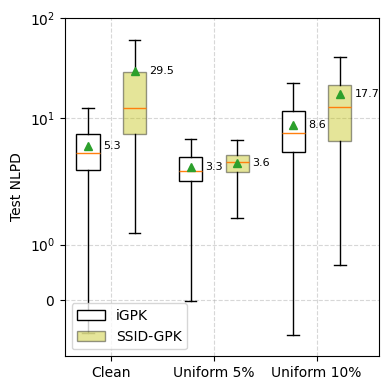

In [ ]:
if True:
    labels = list(NLPD_Test.keys())

    data, positions, xticks = [], [], []

    pos = 1
    for label in labels:
        igpk = NLPD_Test[label]['iGPK'].numpy()
        ssid = NLPD_Test[label]['SSID-GPK'].numpy()
        igpk = remove_outliers(igpk)
        ssid = remove_outliers(ssid)
        # Add both models for this label
        data.extend([igpk, ssid])
        positions.extend([pos, pos + 1])

        # Center tick between the two boxes
        xticks.append(pos + 0.5)

        pos += 2.2  # spacing between groups

    fig, ax = plt.subplots(figsize=(4, 4))

    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showmeans=True, showfliers=False)

    # Optional: color coding
    for i, patch in enumerate(bp['boxes']):
        if i % 2 == 0:
            patch.set_facecolor('w')   # iGPK
        else:
            patch.set_facecolor('y') # SSID-GPK
            patch.set_alpha(0.4)

    # X-axis formatting
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel("Test NLPD")
    ax.set_yscale('symlog')
    ax.set_ylim((-1.0, 1e2))
    xmin, xmax = ax.get_xlim()
    ax.set_xlim((xmin, xmax*1.05))

    # Legend
    ax.legend([bp["boxes"][0], bp["boxes"][1]],
                ["iGPK", "SSID-GPK"],
                loc="lower left")

    # --- After creating the boxplot ---
    for i, (d, x) in enumerate(zip(data, positions)):
        mean_val = np.mean(d)

        ax.text(
            x+0.32, mean_val ,
            f"{mean_val:.1f}",
            ha='left', va='center',
            fontsize=8
        )

    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [94]:
def _diag_std_from_cov(Xcvhat, LB=1e-8):
    # Xcvhat: (nTraj, n, n, N) -> std: (nTraj, n, N)
    nTraj, n, _, N = Xcvhat.shape
    temp = torch.clamp(torch.sqrt(
        torch.abs(torch.diagonal(Xcvhat, dim1=1, dim2=2))), min=LB)
    return torch.reshape(temp, (nTraj, n, N))


def coverage_curve(Xhat, Xcvhat, SimData, sim_offset=0, alphas=None, reduce="mean"):
    """
    Compute empirical coverage for 1D normal intervals across a grid of nominal levels.
    Args:
        Xhat:     (nTraj, n, N) predictive mean
        Xcvhat:   (nTraj, n, n, N) predictive covariance
        SimData:  (nTraj_total, n, N_total) ground truth
        sim_offset: offset index in SimData (e.g., nTrain for test set)
        alphas: list/1D-tensor of nominal coverages in [0,1] (e.g., 0.50..0.99)
        reduce: "mean" → average over states; "none" → return per-state coverage
    Returns:
        alphas (tensor), empirical (tensor of shape (len(alphas),) or (len(alphas), n))
    """
    if alphas is None:
        alphas = torch.linspace(0.50, 0.99, steps=50, device=Xhat.device)
    alphas = torch.as_tensor(alphas, dtype=Xhat.dtype, device=Xhat.device)

    # Standard normal quantile via erfinv: z = sqrt(2)*erfinv(alpha)
    # (Strictly, two-sided interval half-width uses z such that P(|Z|<=z)=alpha, i.e., z = Φ^{-1}((1+alpha)/2))
    from torch import special
    z = torch.special.ndtri((1 + alphas) / 2)  # (A,)

    y_true = SimData[sim_offset:sim_offset +
                     Xhat.shape[0], :, :Xhat.shape[2]]  # (nTraj, n, N)
    mu = Xhat
    sigma = _diag_std_from_cov(Xcvhat)
    nT, n, N = mu.shape
    # Broadcast: for each alpha/z, build interval and test coverage
    # Shapes:
    #   mu, sigma, y_true : (T, n, N)
    #   z[:,None,None,None] → (A,1,1,1)
    lower, upper = torch.zeros((len(alphas), nT, n, N)), torch.zeros(
        (len(alphas), nT, n, N))
    for i in range(alphas.shape[0]):
        lower[i, :, :, :] = mu - z[i] * sigma
        upper[i, :, :, :] = mu + z[i] * sigma
    inside = (y_true >= lower) & (y_true <= upper)
    emp_coverage_state = inside.float().mean(dim=(1, 3))
    # lower = mu. - z.view(-1, 1, 1, 1) * sigma.unsqueeze(0)  # (A,T,n,N)
    # upper = mu.unsqueeze(0) + z.view(-1, 1, 1, 1) * \
    #     sigma.unsqueeze(0)  # (A,T,n,N)
    # inside = (y_true.unsqueeze(0) >= lower) & (
    #     y_true.unsqueeze(0) <= upper)  # (A,T,n,N)

    # Per-state empirical coverage
    # emp_state = inside.float().mean(dim=(1, 3))  # (A, n) avg over traj & time

    if reduce == "mean":
        # mean over states, keep one value per alpha: (A,)
        return alphas, emp_coverage_state.mean(dim=1)        # <-- FIXED
    elif reduce == "none":
        return alphas, emp_coverage_state
    else:
        raise ValueError("reduce must be 'mean' or 'none'")
    

def miscalibration_area(alphas, empirical):
    """
    L1 area between empirical and nominal coverage curves.
    Args:
        alphas:    (A,)
        empirical: (A,) mean curve (use reduce='mean') or (A,n) per-state
    Returns:
        scalar if 1D, or (n,) if per-state
    """
    # Trapezoidal rule on |emp - alpha|
    diff = (empirical - alphas.unsqueeze(-1)
            ) if empirical.ndim == 2 else (empirical - alphas)
    area = torch.trapz(diff.abs(), alphas, dim=0)
    return area


def compare_coverage_curves(
    alphas1, emp_state1,
    alphas2, emp_state2,
    save_path=None
):
    """
    Compare two empirical coverage curves (SSID-GPK vs iGPK).

    Args:
        alphas1, emp_state1: tensors for first model (SSID-GPK)
        alphas2, emp_state2: tensors for second model (iGPK)
        system_name (str): name of the system for plot title
        split (str): 'train' or 'test'
        save_path (str, optional): if given, saves plot instead of showing
    """

    # Ensure torch tensors → numpy arrays
    miscal_area1 = miscalibration_area(100*alphas1, 100*emp_state1)
    miscal_area2 = miscalibration_area(100*alphas2, 100*emp_state2)
    alphas1 = alphas1.detach().cpu().numpy() if torch.is_tensor(alphas1) else alphas1
    emp_state1 = emp_state1.detach().cpu().numpy(
    ) if torch.is_tensor(emp_state1) else emp_state1
    alphas2 = alphas2.detach().cpu().numpy() if torch.is_tensor(alphas2) else alphas2
    emp_state2 = emp_state2.detach().cpu().numpy(
    ) if torch.is_tensor(emp_state2) else emp_state2

    # Plot
    
    plt.figure(figsize=(4, 4))
    plt.plot(alphas1 * 100, emp_state1
             * 100, 'o-', lw=2,
             label=f"SSID-GPK")
    plt.plot(alphas2 * 100, emp_state2
             * 100, 's--', label=f"iGPK", lw=2)
    plt.plot([50, 100], [50, 100], 'k--', alpha=0.7, label="Ideal")

    plt.xlabel("Nominal Coverage (%)", fontsize=11)
    plt.ylabel("Empirical Coverage (%)", fontsize=11)
    # plt.title(f"{system_name} ({split.capitalize()} Set)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.8)
    plt.legend(frameon=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

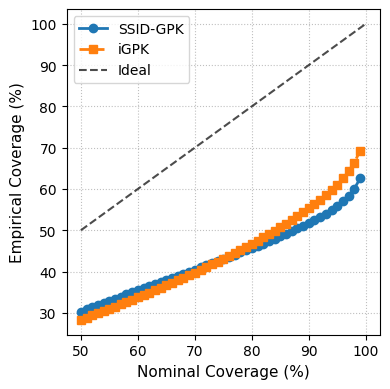

In [95]:
noise_case = 'Uniform 10%'
alphas = torch.linspace(0.50, 0.99, steps=50)
a_te_i, emp_te_i = coverage_curve(
    Xhat_Test[noise_case]['iGPK'],  Xcvhat_Test[noise_case]['iGPK'],  SimData_clean, sim_offset=0, alphas=alphas, reduce="mean")

# SSID-GPK
a_te_s, emp_te_s = coverage_curve(
    Xhat_Test[noise_case]['SSID-GPK'],  Xcvhat_Test[noise_case]['SSID-GPK'],  SimData_clean, sim_offset=0, alphas=alphas, reduce="mean")

compare_coverage_curves(a_te_s, emp_te_s, a_te_i, emp_te_i)

C:\Users\abhig\AppData\Local\Temp\ipykernel_28716\2250321994.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  line, = axes[i].plot(t, mu_vec[i] + std_vec[i]*Xtraj[i], label=label, alpha=1, linewidth=1)
C:\Users\abhig\AppData\Local\Temp\ipykernel_28716\2250321994.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigma_i = std_vec[i]*np.sqrt(var_i)
C:\Users\abhig\AppData\Local\Temp\ipykernel_28716\2250321994.py:39: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (mu_vec[i] + std_vec[i]*Xtraj[i]) - 2*sigma_i,
C:\Users\abhig\AppData\Local\Temp\ipykernel_28716\2250321994.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (

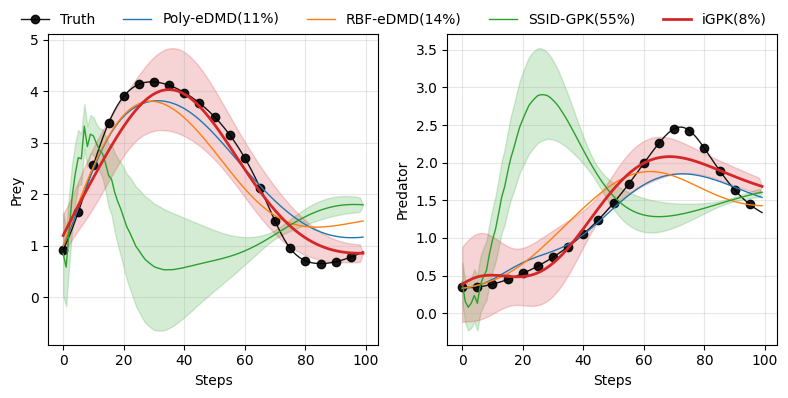

In [93]:
# Trajectory Plot
noise_case = 'Uniform 10%'
_, idx = torch.min(NRMSE_Test[noise_case]['iGPK'].mean(dim=1), dim=-1, keepdim=False)
traj_idx = idx.item()
# State labels (shown on y-axis for each stacked subplot)
state_labels = [r'Prey', r'Predator']

# Get time length from first available model
first_model = next(v for v in Xhat_Test.values() if v is not None)
T = Xhat_Test[noise_case]['iGPK'].shape[2]
t = np.arange(T)
t = t

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=False)
for i in range(2):
    line, = axes[i].plot(t, mu_vec[i] + std_vec[i]*SimData_clean[traj_idx, i, :N], label='Truth', alpha=0.9, linewidth=1, color='black', marker='o', markevery=5)
    for model_name, Xhat in Xhat_Test[noise_case].items():
        # (num_states, num_time_steps)
        Xtraj = Xhat[traj_idx].detach().cpu().numpy()
        label = model_name + f'({100*NRMSE_Test[noise_case][model_name][traj_idx].mean():.0f}%)'

        if model_name == 'iGPK':
            line, = axes[i].plot(t, mu_vec[i] + std_vec[i]*Xtraj[i], label=label, alpha=1, linewidth=2)
        else:
            line, = axes[i].plot(t, mu_vec[i] + std_vec[i]*Xtraj[i], label=label, alpha=1, linewidth=1)
        # axes[i].set_yscale('symlog')
        # axes[i].set_xlim((0, 1.9))

        # Add ±1 sigma shaded band if covariance exists for this model
        # if model_name in Xcvhat_Test[noise_case]:
        if model_name == 'iGPK' or model_name == 'SSID-GPK':
            # Variance of state i over time is diagonal entry [i,i,:]
            var_i = Xcvhat_Test[noise_case][model_name][traj_idx, i, i, :].detach().cpu().numpy()
            var_i = np.abs(var_i)  # numerical safety
            sigma_i = std_vec[i]*np.sqrt(var_i)

            axes[i].fill_between(
                t,
                (mu_vec[i] + std_vec[i]*Xtraj[i]) - 2*sigma_i,
                (mu_vec[i] + std_vec[i]*Xtraj[i]) + 2*sigma_i,
                color=line.get_color(),
                alpha=0.2
            )

# Formatting
for i, ax in enumerate(axes):
    ax.set_ylabel(state_labels[i])
    ax.grid(True, alpha=0.3)

for i in range(2):
    axes[i].set_xlabel('Steps')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Random Testing Sandbox

### Test get_iGPK_fcn

Heuristic Kernel-lengthscale param found to be 2.507e+00
==== Starting iGPK Model Identification ====
iter=0, traj_idx=[3, 38, 53, 48, 34, 25, 23, 6, 8, 5, 19, 35, 52, 12, 29]
iter=1, traj_idx=[8, 13, 17, 48, 1, 55, 25, 53, 43, 29, 22, 38, 39, 14, 59]
iter=2, traj_idx=[12, 32, 56, 24, 36, 38, 13, 28, 34, 40, 53, 1, 11, 44, 25]
iter=3, traj_idx=[15, 16, 24, 44, 55, 30, 45, 54, 12, 38, 8, 13, 32, 52, 11]
iter=4, traj_idx=[57, 4, 50, 5, 39, 21, 31, 38, 12, 18, 25, 58, 15, 47, 28]
iter=5, traj_idx=[21, 35, 9, 57, 18, 19, 55, 53, 42, 16, 22, 15, 1, 7, 3]
iter=6, traj_idx=[31, 27, 23, 52, 15, 20, 59, 33, 53, 0, 29, 37, 24, 4, 21]
iter=7, traj_idx=[27, 11, 12, 54, 25, 35, 26, 2, 13, 3, 7, 40, 15, 10, 33]
iter=8, traj_idx=[2, 10, 45, 58, 48, 36, 53, 52, 51, 23, 31, 0, 16, 14, 3]
iter=9, traj_idx=[32, 1, 56, 47, 15, 7, 3, 28, 33, 42, 38, 58, 14, 30, 13]
Cost History: [0.08856771886348724, 0.08611901849508286, 0.08469931036233902, 0.08568455278873444, 0.08372124284505844, 0.09013988822698593, 0.

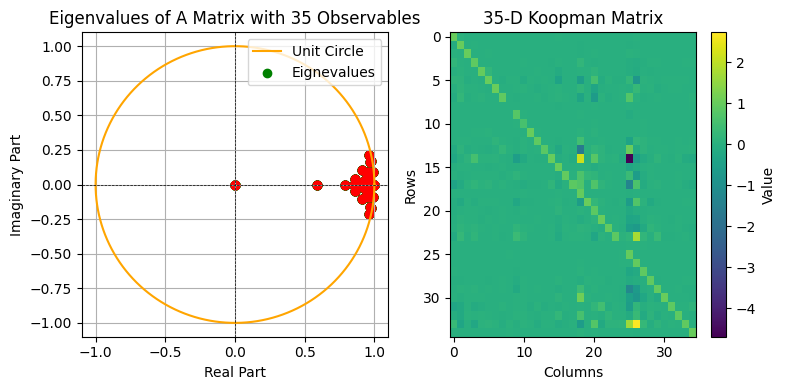

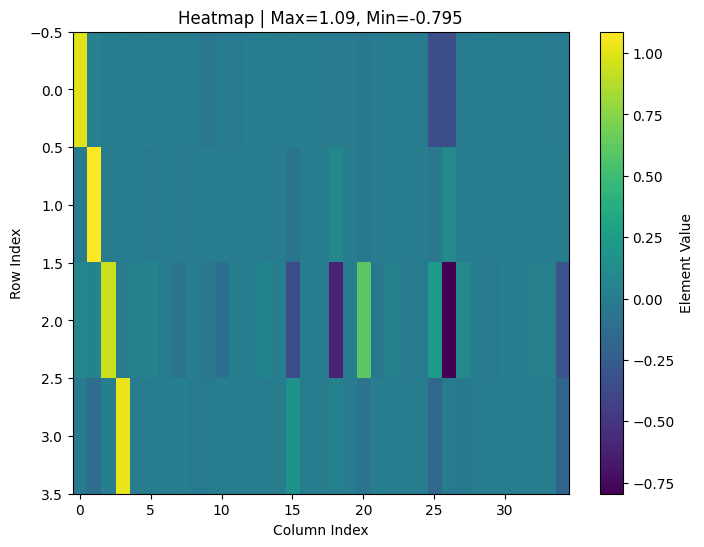

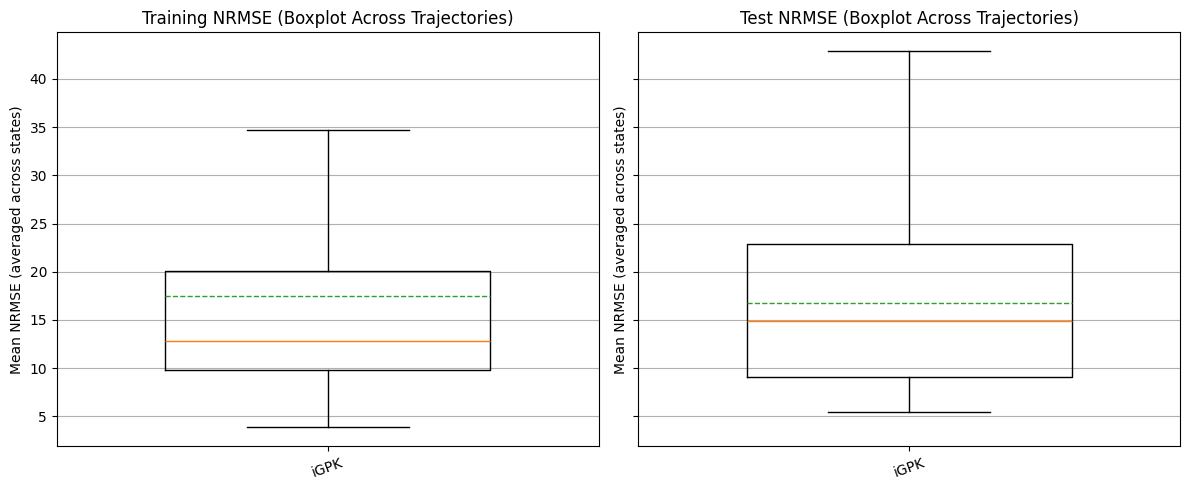

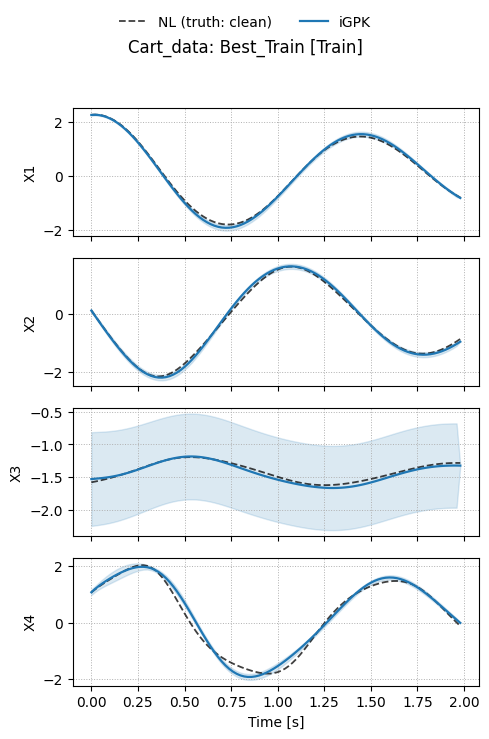

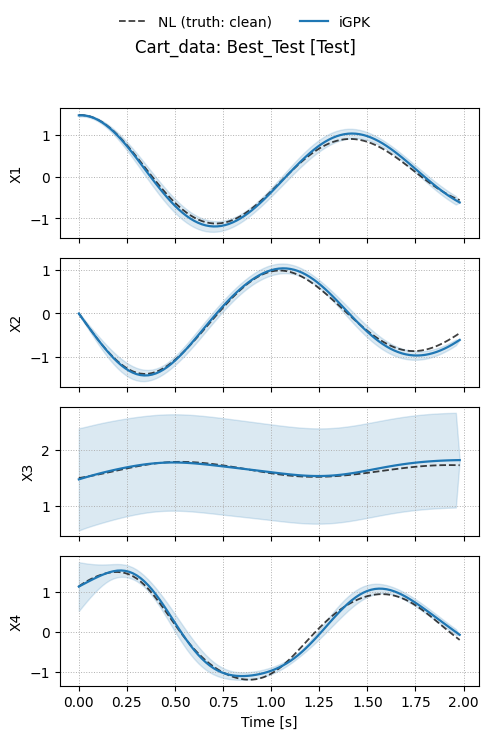

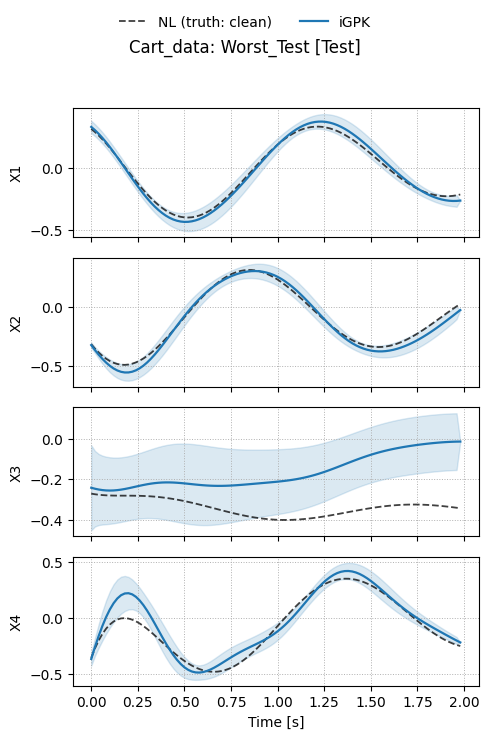

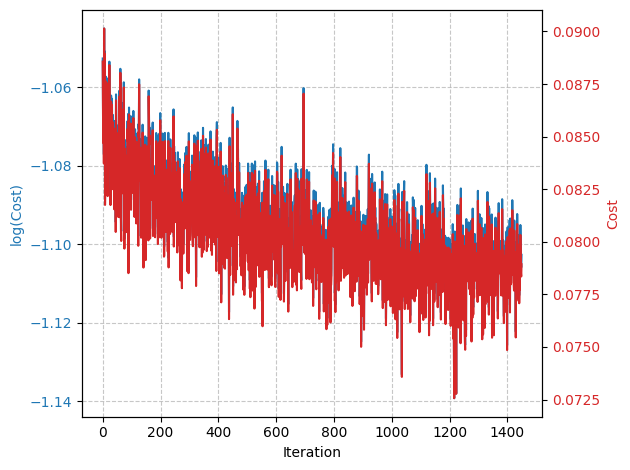

In [1]:
import os
import gc
import itertools
from datetime import datetime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import GPKoopman as gpk
from get_iGPK_fcn import get_iGPK

import warnings
warnings.filterwarnings("ignore")


def find_hp_init(SimData: torch.tensor, nTrain: int) -> float:
    def _stack_snapshot_pairs(batch: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
        """
        batch: (nB, n, T+1)
        Returns:
            X: (nB*T, n), Y: (nB*T, n)
        """
        n = batch.shape[1]
        X = batch[:, :, :-1].permute(0, 2, 1).reshape(-1,
                                                      n).detach().cpu().numpy()
        Y = batch[:, :,  1:].permute(
            0, 2, 1).reshape(-1, n).detach().cpu().numpy()
        return X, Y
    # ---------- build stacked (X,Y) ----------
    train_batch = SimData[:nTrain]
    Xtr, _ = _stack_snapshot_pairs(train_batch)
    Npts = Xtr.shape[0]

    max_pairs_to_store = 5_000_000  # ~5 million floats ~ 40MB
    num_pairs = Npts * (Npts - 1) // 2

    if num_pairs <= max_pairs_to_store:
        # Store all distances (exact median).
        dists = np.empty(num_pairs, dtype=np.float32)
        k = 0
        for i in range(Npts - 1):
            diff = Xtr[i + 1:] - Xtr[i]                 # (Npts-i-1, n)
            di = np.sqrt(np.sum(diff * diff, axis=1))    # (Npts-i-1,)
            dists[k: k + di.size] = di
            k += di.size
        hp_init = float(np.median(dists))
        return hp_init
    else:  # fallback for huge datasets
        rng = np.random.default_rng(0)
        # sample up to the cap
        sample_pairs = min(max_pairs_to_store, num_pairs)
        idx_i = rng.integers(0, Npts, size=sample_pairs, endpoint=False)
        idx_j = rng.integers(0, Npts, size=sample_pairs, endpoint=False)

        # Ensure i != j (resample conflicts)
        mask = idx_i == idx_j
        while np.any(mask):
            idx_j[mask] = rng.integers(
                0, Npts, size=int(mask.sum()), endpoint=False)
            mask = idx_i == idx_j

        diffs = Xtr[idx_i] - Xtr[idx_j]
        dists = np.sqrt(np.sum(diffs * diffs, axis=1))
        hp_init = float(np.median(dists))
        return hp_init


SYSTEM_NAME = 'Cart_data'
TRAIN_FRAC, TEST_FRAC = 0.6, 0.4
CLIP = None
LIFTING_ORDER = 35
NOISE_TYPE = 'gaussian'
NOISE_INTENSITY = 0.0
NOISE_SEED = 100
# unused, samples, iterations, inner iterations
MAX_ITER = 50000
OPT_WEIGHTS = [1.0, 1.0, 0.0]
ROUTINE = "Z-only"
TRAIN_METHOD = "Zero-Mean"
DEVICE = "cuda:0"
SEED_Z = 1234
SEED_HP = 1234
traj_batch_size = 15
FULL_COST_EVAL_EVERY = 50
# 1) Load + normalize
SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
    SYSTEM_NAME, TRAIN_FRAC, TEST_FRAC, clip=CLIP)
SimData_clean, mu_vec, std_vec = gpk.normalize_data(
    SimData_raw, nTrain, N)

# 2) Find Initial Hyperparameter
SimData = gpk.add_noise(SimData_clean, noise_type=NOISE_TYPE,
                        intensity=NOISE_INTENSITY, seed=NOISE_SEED)
HP_INIT = find_hp_init(SimData, nTrain)
print(f'Heuristic Kernel-lengthscale param found to be {HP_INIT:.3e}')
hp_scale = [None, HP_INIT, None]

# 2) Noise


print(f'==== Starting iGPK Model Identification ====')
# results = get_iGPK(SimData, nTrain, nTest, lifted_order,
#                    MAX_ITER, sgd_lr=1e-3, sgd_m=0.75, stop_tol=1e-3,
#                    opt_weights=[1.0, 1.0, 0.0], routine=ROUTINE,
#                    train_method="Zero-Mean", hp_scale=[None, HP_INIT, None],
#                    traj_batch_size=nTrain, full_cost_eval_every=50)

results = get_iGPK(
    SimData=SimData,
    nTrain=nTrain,
    nTest=nTest,
    lifting_order=LIFTING_ORDER,
    max_iter=MAX_ITER,
    sgd_lr=1e-3,
    sgd_m=0.75,
    stop_tol=1e-3,
    opt_weights=OPT_WEIGHTS,
    routine=ROUTINE,
    train_method=TRAIN_METHOD,
    hp_scale=hp_scale,
    device=DEVICE,
    seed_z=SEED_Z,
    seed_hp=SEED_HP,

    # NEW: trajectory-wise batch-SGD arguments
    traj_batch_size=traj_batch_size,
    full_cost_eval_every=FULL_COST_EVAL_EVERY,
)

if True:    # All Post-Processing and Outputs
    # unpack iGPK
    ObsManager = results["ObsManager"]
    A_igpk, C_igpk = results["A"], results["C"]
    XhatTrain, XcvhatTrain, TrainNRMSE = results["Train"][
        "Xhat"], results["Train"]["Xcv"], results["Train"]["NRMSE"]
    XhatTest,  XcvhatTest,  TestNRMSE = results["Test"][
        "Xhat"],  results["Test"]["Xcv"],  results["Test"]["NRMSE"]
    t_iGPK, total_epochs = results['history']['opt_time'], results[
        "history"]['iters']
    
    print(f'Lifted Model Order:         {LIFTING_ORDER:d}')
    print(f'Total Epochs executed:      {total_epochs:d}')
    print(f'Learning Time:              {t_iGPK:.2f} seconds')
    
    gpk.plot_eigen(A_igpk)
    gpk.MatViz(C_igpk, 'heat')
    # TrainNRMSE = TrainNRMSE.clamp(max=1.5)
    # TestNRMSE = TestNRMSE.clamp(max=1.5)
    gpk.plot_NRMSE_metrics([TrainNRMSE*100], [TestNRMSE*100], ['iGPK'])

    # 6) indices + timebase
    idx_trainMIN = torch.argmin(TrainNRMSE.mean(dim=1))
    idx_testMIN = torch.argmin(TestNRMSE.mean(dim=1))
    idx_testMAX = torch.argmax(TestNRMSE.mean(dim=1))
    time_arr = torch.arange(0., ts * (SimData.shape[2] - 1), ts)
    print(f'Median Test NMRSE:          {100*TestNRMSE.mean(dim=1).median():.2f}%')
    print(f'Mean Test NMRSE:            {100*float(TestNRMSE.mean()):.2f}%')

    # 7) pack models for overlay plot
    models = [
        {"name": "iGPK", "train": {"Xhat": XhatTrain, "Xcvhat": XcvhatTrain},
            "test": {"Xhat": XhatTest, "Xcvhat": XcvhatTest}}
    ]

    # a) 3 trajectory overlays
    for (which, idx, split, sim_offset, suffix) in [
        ("best-train", idx_trainMIN, "train", 0,         "Best_Train"),
        ("best-test",  idx_testMIN,  "test",  nTrain,    "Best_Test"),
        ("worst-test", idx_testMAX,  "test",  nTrain,    "Worst_Test"),
    ]:
        gpk.compare_model_predictions(
            time=time_arr, models=models, SimData=SimData, idx=idx, N=(
                SimData.shape[2]-1),
            system_name=SYSTEM_NAME, title_suffix=suffix, split=split, sim_offset=sim_offset,
            compare_to="SimData_clean", SimData_clean=SimData_clean, sigma=1.0
        )

    cost_history = results["history"].get("cost", None)
    # Plot Cost History
    fig, ax1 = plt.subplots()
    color = 'tab:blue'
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('log(Cost)', color=color)
    ax1.plot(torch.log10(torch.abs(cost_history)), color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Cost', color=color)
    ax2.plot(cost_history, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    fig.tight_layout()

    print(f'Post-MLE Cost: {results['history']['post_mle_cost']:.3e}')
    # plt.plot(results["history"]['mean_grad'])

    ### NLPD Calulation
    def _nlpd_one(y, mu, S, jitter=1e-8):
        """
        NLPD for a single multivariate Gaussian y~N(mu,S).
        y, mu: (n,)
        S: (n,n) covariance
        Returns scalar (float)
        """
        n = y.numel()
        S = 0.5 * (S + S.T)  # symmetrize
        S = S + jitter * torch.eye(n, dtype=S.dtype)
        try:
            L = torch.linalg.cholesky(S)
            logdet = 2.0 * torch.log(torch.diag(L)).sum()
            diff = (y - mu).view(n, 1)
            sol = torch.cholesky_solve(diff, L)
            quad = float((diff.T @ sol).item())
            return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)
        except Exception:
            # Diagonal fallback
            diag = torch.clamp(torch.diagonal(S), min=jitter)
            logdet = torch.log(diag).sum()
            quad = ((y - mu) ** 2 / diag).sum().item()
            return 0.5 * (n * math.log(2.0 * math.pi) + float(logdet) + quad)

    def _nlpd_per_traj(Xhat, Xcv, GT):
        """
        Average NLPD per trajectory across time-steps.
        returns (nTraj,) tensor
        """
        nTraj, n, N = Xhat.shape
        traj_vals = torch.zeros(nTraj, dtype=Xhat.dtype)
        for j in range(nTraj):
            acc = 0.0
            for k in range(N):
                acc += _nlpd_one(GT[j, :, k], Xhat[j, :, k],
                                torch.clamp(torch.abs(Xcv[j, :, :, k]), min=1e-6))
            traj_vals[j] = acc / N
        return traj_vals

    def _ms(x):
        return float(x.mean()), float(x.std(unbiased=False))

    GT_test = SimData[nTrain:nTrain+nTest, :, :N-1]  # (nTest, n, N)

    nlpd_traj_test_igpk = gpk.nlpd_per_traj(
        XhatTest[:, :, :N-1], XcvhatTest[:, :, :, :N-1], GT_test).detach().cpu()

    # Print summary
    m, s = _ms(nlpd_traj_test_igpk)
    print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")

    plt.show()


### Init

In [1]:
## --- IMPORTS --- ###
import GPKoopman as gpk
import torch
import matplotlib.pyplot as plt
import math
import numpy as np
import time
from itertools import combinations_with_replacement

import warnings
warnings.filterwarnings("ignore")

# from get_iGPK_new import get_iGPK

def find_hp_init(SimData: torch.tensor, nTrain: int) -> float:
    def _stack_snapshot_pairs(batch: torch.Tensor) -> tuple[np.ndarray, np.ndarray]:
        """
        batch: (nB, n, T+1)
        Returns:
            X: (nB*T, n), Y: (nB*T, n)
        """
        n = batch.shape[1]
        X = batch[:, :, :-1].permute(0, 2, 1).reshape(-1,
                                                      n).detach().cpu().numpy()
        Y = batch[:, :,  1:].permute(
            0, 2, 1).reshape(-1, n).detach().cpu().numpy()
        return X, Y
    # ---------- build stacked (X,Y) ----------
    train_batch = SimData[:nTrain]
    Xtr, _ = _stack_snapshot_pairs(train_batch)
    Npts = Xtr.shape[0]

    max_pairs_to_store = 5_000_000  # ~5 million floats ~ 40MB
    num_pairs = Npts * (Npts - 1) // 2

    if num_pairs <= max_pairs_to_store:
        # Store all distances (exact median).
        dists = np.empty(num_pairs, dtype=np.float32)
        k = 0
        for i in range(Npts - 1):
            diff = Xtr[i + 1:] - Xtr[i]                 # (Npts-i-1, n)
            di = np.sqrt(np.sum(diff * diff, axis=1))    # (Npts-i-1,)
            dists[k: k + di.size] = di
            k += di.size
        hp_init = float(np.median(dists))
        return hp_init
    else:  # fallback for huge datasets
        rng = np.random.default_rng(0)
        # sample up to the cap
        sample_pairs = min(max_pairs_to_store, num_pairs)
        idx_i = rng.integers(0, Npts, size=sample_pairs, endpoint=False)
        idx_j = rng.integers(0, Npts, size=sample_pairs, endpoint=False)

        # Ensure i != j (resample conflicts)
        mask = idx_i == idx_j
        while np.any(mask):
            idx_j[mask] = rng.integers(
                0, Npts, size=int(mask.sum()), endpoint=False)
            mask = idx_i == idx_j

        diffs = Xtr[idx_i] - Xtr[idx_j]
        dists = np.sqrt(np.sum(diffs * diffs, axis=1))
        hp_init = float(np.median(dists))
        return hp_init


In [2]:
def generate_monomial_powers(nx: int, total_orders=(2, 3)):
    """
    Return exponent tuples for all unique monomials whose total degree
    is in `total_orders`.

    Example for nx=2:
        degree 2: (2,0), (1,1), (0,2)
        degree 3: (3,0), (2,1), (1,2), (0,3)
    """
    power_list = []

    for order in total_orders:
        for combo in combinations_with_replacement(range(nx), order):
            powers = [0] * nx
            for idx in combo:
                powers[idx] += 1
            power_list.append(tuple(powers))

    return power_list

# @torch.no_grad()
def build_G_cache(manager, X, Xplus) -> tuple[torch.Tensor]:
    """
    Build detached G caches for Z-only optimization.

    Returns
    -------
    G_X      : (nz, S, r)
    G_Xplus  : (nz, S, r)

    where:
        nz = number of observables
        S = N*nT
        r = number of virtual targets
    """
    nz = manager.num_obs
    r = manager.observables[0].Ns # Z.shape[0]
    S = X.shape[1]

    G_X_list, G_Xplus_list = [], []

    for i in range(nz):
        obs = manager.observables[i]

        Gi = obs.forward_G(X)       # X : (nx, N*nT) -> Gi : (N*nT, r)
        Gpi = obs.forward_G(Xplus)  # (N*nT, r)

        G_X_list.append(Gi)
        G_Xplus_list.append(Gpi)

    G_X = torch.stack(G_X_list, dim=0).contiguous()
    G_Xplus = torch.stack(G_Xplus_list, dim=0).contiguous()

    return G_X, G_Xplus

def get_cost_simple_fast(
    Z, X, G_X, G_Xplus,
    lambda1=1.0, lambda2=1.0, lambda3=1.0,
    jitter=1e-6, Mp_X0=None, Mp_X=None, Mp_Xplus=None):
    """
    Fast version of get_cost_simple.

    Avoids explicitly forming:
        M_pinvM = M_pinv @ M

    """

    nz = Z.shape[1]
    nT = int(Z.shape[0])
    dtype = G_X.dtype
    device = G_X.device

    # ------------------------------------------------------------
    # 1. Build lifted mean matrices M and Mplus
    # ------------------------------------------------------------
    # prior_mean = [M_X0, M_X, M_Xplus]

    if Mp_X0 is not None:
        lifted_residual = Z - Mp_X0
        M = Mp_X + torch.einsum("isr,ri->is", G_X, lifted_residual)
        Mplus = Mp_Xplus + torch.einsum("isr,ri->is", G_Xplus, lifted_residual)
    else:
        M = torch.einsum("isr,ri->is", G_X, Z)
        Mplus = torch.einsum("isr,ri->is", G_Xplus, Z)

    # ------------------------------------------------------------
    # 2. Compute Gram matrix in lifted space
    # ------------------------------------------------------------
    eye_p = torch.eye(nz, dtype=dtype, device=device)
    Gram = M @ M.mT # (p, p)

    try:
        L = torch.linalg.cholesky(Gram + jitter * eye_p)
    except RuntimeError:
        try:
            L = torch.linalg.cholesky(Gram + (10*jitter) * eye_p)
        except RuntimeError:
            L = torch.linalg.cholesky(Gram + (100*jitter) * eye_p)

    # ------------------------------------------------------------
    # 3. Compute B P_M without forming P_M
    # ------------------------------------------------------------
    # B contains both terms whose projection residual we need:
    #   Mplus P_M and X P_M
    B = torch.cat([Mplus, X], dim=0)         # (p+n, S)

    # coeff = (B M.T) (M M.T + eps I)^(-1)
    # Use cholesky_solve for stability:
    BMt = B @ M.mT                          # (p+n, p)
    coeff = torch.cholesky_solve(BMt.mT, L).mT  # (p+n, p)

    residual = B - coeff @ M                # (p+n, S)

    R1 = residual[:nz, :]                    # Mplus projection residual
    R2 = residual[nz:, :]                    # X projection residual

    # ------------------------------------------------------------
    # 4. Cost
    # ------------------------------------------------------------
    # if squared:
    #     # Faster and usually better conditioned than Frobenius norm.
    #     # This corresponds to the usual squared-Frobenius objective.
    #     cost1 = R1.square().sum()
    #     cost2 = R2.square().sum()
    # else:
        # Preserves your original objective exactly.
    cost1 = torch.linalg.matrix_norm(R1, ord="fro")
    cost2 = torch.linalg.matrix_norm(R2, ord="fro")
    # cost3 = torch.
    cost3 = 0.0 # torch.linalg.matrix_norm(
        # ( Z[:nT,:] - Z[nT:, :] @ coeff[:nz, :].mT ),
        # ord='fro'
        # )

    return ((lambda1 * cost1) + (lambda2 * cost2) + cost3) / (nz * nT)

In [3]:
def get_iGPK(
    SimData: torch.tensor,          # (num_traj, n, N+1)
    nTrain: int, nTest: int,
    lifting_order: int = 10,
    max_iter: int = 100,
    sgd_lr : float = 0.01, sgd_m : float = 0.82,
    opt_weights: list[float] = [1., 1., 0.01],
    routine: str = "Z_only",        # "Z_only" or "SpacedOpt"
    train_method: str = "Horizon",  # "Horizon" or "K-Means"
    hp_scale: list = [None, 1.0, None],  # [hp1, hp2, mu]
    device: str | torch.device = "cuda:0",
    seed_z: int = 1234,
    seed_hp: int = 1234
):
    """
    Train iGPK, build Koopman (A, C), simulate train/test, and return predictions, covariances, NRMSE.

    NOTE: Data loading & noise addition remain outside. Pass prepped SimData in.
    """
    SimData = SimData.to(dtype=torch.float32)
    import warnings
    warnings.filterwarnings("ignore")
    # Shapes & basic splits
    nx = SimData.shape[1]
    N = SimData.shape[2] - 1
    nz = int(lifting_order)
 
    # Build concatenated matrices and ICs from SimData
    # Xall = torch.cat([SimData[j, :, :]
    #                  for j in range(nTrain)], dim=1)    # (nx, (N+1)*nTrain)
    X = torch.cat([SimData[j, :, 0:N]
                  for j in range(nTrain)], dim=1)       # (nx, N*nTrain)
    Xplus = torch.cat([SimData[j, :, 1:]
                      for j in range(nTrain)], dim=1)   # (n, N*nTrain)

    ICsetTrain = torch.cat([SimData[j, :, 0].view(nx, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(nx, 1)
                          for j in range(nTrain, nTrain + nTest)], dim=1)

    t0 = time.perf_counter()
    ObsManager = gpk.GPObservablesManager()

    # Initialize manager & decision variable Z (training grid)
    if train_method == "Zero-Mean":
        Xtrain = torch.cat([X[:, j*N : j*N+2]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        Z = torch.nn.Parameter(torch.rand(
            nTrain*2, nz, device=device))   # Virtual Targets, (nTrain, nz)
        for i in range(nz):
            kernel = gpk.GaussianKernel()
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain*2, kernel=kernel,
                prior_mean=None, noise=1e-5, device=device,
                beta=20.0, thresh=20.0, eps=1e-10)
        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    elif train_method == "Monomials":
        Xtrain = torch.cat([X[:, j*N: j*N + 1]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        Z = torch.nn.Parameter(torch.rand(
            nTrain, nz, device=device))   # Virtual Targets, (nTrain, nz)
        
        monomial_powers = generate_monomial_powers(nx, total_orders=(2, 3))
        num_monomial_means = min(nz, len(monomial_powers))
        for i in range(nz):
            kernel = gpk.GaussianKernel()

            if i < num_monomial_means:
                prior_mean = gpk.MonomialMean(powers=monomial_powers[i])
            else:
                prior_mean = None
            
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain, kernel=kernel,
                prior_mean=prior_mean, noise=1e-6, device=device,
                beta=20.0, thresh=20.0, eps=1e-12)

        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
            
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    else:
        raise ValueError(f"Unrecognized train_method: {train_method}")

    # === Optimization ===
    lam1, lam2, lam3 = opt_weights
    iter = 0
    cost_history, grad_history = [], []
    hp_opt_iter = int(0.0001*max_iter)
    num_hpopt = 0
    num_perturb = 0
    G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)
    if train_method == "Monomials":
        Mp_X0 = torch.cat([ObsManager.observables[i].prior_mean(
            Xtrain.to(device=device)) for i in range(nz)], dim=1)
        Mp_X = torch.cat([torch.transpose(ObsManager.observables[i].prior_mean(
            X.to(device=device)), dim0=0, dim1=1) for i in range(nz)], dim=0)
        Mp_Xplus = torch.cat([torch.transpose(ObsManager.observables[i].prior_mean(
            Xplus.to(device=device)), dim0=0, dim1=1) for i in range(nz)], dim=0)

    else:
        Mp_X0, Mp_X, Mp_Xplus = None, None, None

    optimizer = torch.optim.SGD(
        [Z], lr=sgd_lr, momentum=sgd_m, nesterov=True)
    # ObsManager.print_hyperparameters(indices=None)
    while iter < max_iter:
        optimizer.zero_grad(set_to_none=True)
        cost = get_cost_simple_fast(Z, X.to(device=device), G_X, G_Xplus,
                               lambda1=lam1, lambda2=lam2, lambda3=lam3,
                               Mp_X0=Mp_X0, Mp_X=Mp_X, Mp_Xplus=Mp_Xplus)
        cost.backward()
        optimizer.step()
        cost_history.append(cost.item())
        grad_history.append(Z.grad.mean().item())
        iter += 1

        if iter > 1000: # STOPPING CONDITION
            rel_change = float((cost_history[-50] - cost_history[-1]) / cost_history[-50])
            
            if iter > 10000 and rel_change > 0 and rel_change < 1e-6:
                pass #break
            elif rel_change > 0 and rel_change < 1e-5:
                pass
                # with torch.no_grad():
                #     scale = (1.0) * Z.detach().std().clamp(min=1e-8)
                #     Z.add_((scale * (torch.rand_like(Z) - 0.5)))
                #     state = optimizer.state.get(Z, None)
                #     state["momentum_buffer"].zero_()
                #     num_perturb += 1

        if (routine == 'alternating') and (iter < max_iter) and ((iter % 1000) == 0):
            ObsManager.optimize_hyperparameters(
                opt_mu=False, opt_sigma=False, max_iter=2, lr=sgd_lr)
            num_hpopt += 1
            G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)

    # === Retrain GPs at optimal Z & (optionally) optimize hp ===
    optimal_Z = Z.detach()
    for i in range(nz):
        ObsManager.train_observable(i, Xtrain, optimal_Z[:, i].unsqueeze(dim=1))

    ObsManager.optimize_hyperparameters(num_iter=200, lr=0.1, opt_noise=True)
    print(num_perturb)
    # === Koopman A, C ===
    A, C = gpk.getKoopman(ObsManager, X, Xplus, nTrain, stateAug=False)
    t_iGPK = time.perf_counter() - t0
    # ObsManager.print_hyperparameters(indices=None)
    # ===================================
    # ======= Simulate & evaluate =======
    # ===================================
    
    #   Train split (offset 0), Test split (offset nTrain)
    XhatTrain, XcvTrain, TrainNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTrain, SimData, traj_offset=0)
    XhatTest,  XcvTest,  TestNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTest,  SimData, traj_offset=nTrain)

    # === Package results ===
    return {
        "ObsManager": ObsManager,
        "A": A, "C": C,
        "ICsetTrain": ICsetTrain.detach().cpu(),
        "ICsetTest":  ICsetTest.detach().cpu(),
        "Train": {
            "Xhat": XhatTrain,      # (nTrain, nx, N)
            "Xcv":  XcvTrain,       # (nTrain, nx, nx, N)
            "NRMSE": TrainNRMSE     # (nTrain, nx)
        },
        "Test": {
            "Xhat": XhatTest,       # (nTest, nx, N)
            "Xcv":  XcvTest,        # (nTest, nx, nx, N)
            "NRMSE": TestNRMSE      # (nTest, nx)
        },
        "history": {
            "cost": torch.tensor(cost_history).detach().cpu(),
            "iters": iter,
            "opt_time": t_iGPK,
            "mean_grad": grad_history,
        },
    }

In [27]:
def get_iGPK2(
    SimData: torch.tensor,          # (num_traj, n, N+1)
    nTrain: int, nTest: int,
    lifting_order: int = 10,
    max_iter: int = 100,
    sgd_lr : float = 0.01, sgd_m : float = 0.82,
    opt_weights: list[float] = [1., 1., 0.01],
    routine: str = "Z_only",        # "Z_only" or "SpacedOpt"
    train_method: str = "Horizon",  # "Horizon" or "K-Means"
    hp_scale: list = [None, 1.0, None],  # [hp1, hp2, mu]
    device: str | torch.device = "cuda:0",
    seed_z: int = 1234,
    seed_hp: int = 1234
):
    """
    Train iGPK, build Koopman (A, C), simulate train/test, and return predictions, covariances, NRMSE.

    NOTE: Data loading & noise addition remain outside. Pass prepped SimData in.
    """
    SimData = SimData.to(dtype=torch.float32)
    import warnings
    warnings.filterwarnings("ignore")
    # Shapes & basic splits
    nx = SimData.shape[1]
    N = SimData.shape[2] - 1
    nz = int(lifting_order)
 
    # Build concatenated matrices and ICs from SimData
    # Xall = torch.cat([SimData[j, :, :]
    #                  for j in range(nTrain)], dim=1)    # (nx, (N+1)*nTrain)
    X = torch.cat([SimData[j, :, 0:N]
                  for j in range(nTrain)], dim=1)       # (nx, N*nTrain)
    Xplus = torch.cat([SimData[j, :, 1:]
                      for j in range(nTrain)], dim=1)   # (n, N*nTrain)

    ICsetTrain = torch.cat([SimData[j, :, 0].view(nx, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(nx, 1)
                          for j in range(nTrain, nTrain + nTest)], dim=1)

    t0 = time.perf_counter()
    ObsManager = gpk.GPObservablesManager()

    # Initialize manager & decision variable Z (training grid)
    if train_method == "Zero-Mean":
        Xtrain = torch.cat([X[:, j*N : j*N+1]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        # Z = torch.nn.Parameter(torch.rand(
        #     nTrain, nz, device=device))   # Virtual Targets, (nTrain, nz)
        Z_raw = torch.zeros((nTrain, nz), device=device)
        monomial_powers = generate_monomial_powers(nx, total_orders=(1, 2, 3))
        num_monomial_means = min(nz, len(monomial_powers))
        for i in range(nz):
            if i < num_monomial_means:
                monomial = gpk.MonomialMean(powers=monomial_powers[i])
                Z_raw[:, i] = monomial(Xtrain).squeeze(dim=1
                                )
            else:
                monomial = None
                Z_raw[:, i] = torch.rand(nTrain, 1, device=device).squeeze(dim=1)
            
            Z = torch.nn.Parameter(Z_raw)

        for i in range(nz):
            kernel = gpk.GaussianKernel()
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain, kernel=kernel,
                prior_mean=None, noise=1e-4, device=device,
                beta=20.0, thresh=20.0, eps=1e-8)
        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    elif train_method == "Monomials":
        Xtrain = torch.cat([X[:, j*N: j*N + 1]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        Z = torch.nn.Parameter(torch.rand(
            nTrain, nz, device=device))   # Virtual Targets, (nTrain, nz)
        
        monomial_powers = generate_monomial_powers(nx, total_orders=(2, 3))
        num_monomial_means = min(nz, len(monomial_powers))
        for i in range(nz):
            kernel = gpk.GaussianKernel()

            if i < num_monomial_means:
                prior_mean = gpk.MonomialMean(powers=monomial_powers[i])
            else:
                prior_mean = None
            
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain, kernel=kernel,
                prior_mean=prior_mean, noise=1e-6, device=device,
                beta=20.0, thresh=20.0, eps=1e-12)

        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
            
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    else:
        raise ValueError(f"Unrecognized train_method: {train_method}")

    # === Optimization ===
    lam1, lam2, lam3 = opt_weights
    iter = 0
    cost_history, grad_history = [], []
    hp_opt_iter = int(0.0001*max_iter)
    num_hpopt = 0
    num_perturb = 0
    # ------------------------------------------------------------
    # Collect all kernel parameters, excluding GP observation noise
    # ------------------------------------------------------------
    kernel_params = []
    seen_params = set()

    for obs in ObsManager.observables.values():

        # Explicitly freeze GP noise so it does not accumulate gradients
        obs.raw_noise.requires_grad_(False)

        # Collect kernel parameters only
        for param in obs.kernel.optimization_parameters(opt_mu=False):
            if id(param) not in seen_params:
                kernel_params.append(param)
                seen_params.add(id(param))

    # Optional diagnostic
    print(f"Optimizing Z plus {len(kernel_params)} kernel parameters.")

    # ------------------------------------------------------------
    # Prior-mean terms remain fixed and can stay outside the loop
    # ------------------------------------------------------------
    if train_method == "Monomials":
        Mp_X0 = torch.cat([
            ObsManager.observables[i].prior_mean(
                Xtrain.to(device=device)
            )
            for i in range(nz)
        ], dim=1)

        Mp_X = torch.cat([
            torch.transpose(
                ObsManager.observables[i].prior_mean(
                    X.to(device=device)
                ),
                dim0=0, dim1=1
            )
            for i in range(nz)
        ], dim=0)

        Mp_Xplus = torch.cat([
            torch.transpose(
                ObsManager.observables[i].prior_mean(
                    Xplus.to(device=device)
                ),
                dim0=0, dim1=1
            )
            for i in range(nz)
        ], dim=0)

    else:
        Mp_X0, Mp_X, Mp_Xplus = None, None, None

    # ------------------------------------------------------------
    # Joint optimizer: Z + all kernel hyperparameters
    # ------------------------------------------------------------
    optimizer = torch.optim.SGD(
        [
            {"params": [Z], "lr": sgd_lr},
            {"params": kernel_params, "lr": 0.05*sgd_lr},
        ],
        momentum=sgd_m,
        nesterov=True
    )

    # ObsManager.print_hyperparameters(indices=None)

    while iter < max_iter:
        optimizer.zero_grad(set_to_none=True)

        # --------------------------------------------------------
        # Must be recomputed every iteration:
        # G depends on the current kernel hyperparameters
        # --------------------------------------------------------
        G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)

        cost = get_cost_simple_fast(
            Z,
            X.to(device=device),
            G_X,
            G_Xplus,
            lambda1=lam1,
            lambda2=lam2,
            lambda3=lam3,
            Mp_X0=Mp_X0,
            Mp_X=Mp_X,
            Mp_Xplus=Mp_Xplus
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())
        grad_history.append(Z.grad.mean().item())

        iter += 1

        if iter > 1000:  # STOPPING CONDITION
            rel_change = float((cost_history[-50] - cost_history[-1])
                                / cost_history[-50])

            if iter > 10000 and rel_change > 0 and rel_change < 1e-6:
                break
            elif rel_change > 0 and rel_change < 1e-4:
                pass
                # with torch.no_grad():
                #     scale = (1.0) * Z.detach().std().clamp(min=1e-8)
                #     Z.add_((scale * (torch.rand_like(Z) - 0.5)))
                #     state = optimizer.state.get(Z, None)
                #     state["momentum_buffer"].zero_()
                #     num_perturb += 1

        if (iter % 500 == 0):
            print(f'ITER: {iter:06d} || COST: {cost_history[-1]:.3e}')

    # === Retrain GPs at optimal Z & (optionally) optimize hp ===
    optimal_Z = Z.detach()
    for i in range(nz):
        ObsManager.train_observable(i, Xtrain, optimal_Z[:, i].unsqueeze(dim=1))

    # ObsManager.optimize_hyperparameters(num_iter=200, lr=0.1, opt_noise=True)
    print(num_perturb)
    # === Koopman A, C ===
    A, C = gpk.getKoopman(ObsManager, X, Xplus, nTrain, stateAug=False)
    t_iGPK = time.perf_counter() - t0
    # ObsManager.print_hyperparameters(indices=None)
    # ===================================
    # ======= Simulate & evaluate =======
    # ===================================
    
    #   Train split (offset 0), Test split (offset nTrain)
    XhatTrain, XcvTrain, TrainNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTrain, SimData, traj_offset=0)
    XhatTest,  XcvTest,  TestNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTest,  SimData, traj_offset=nTrain)

    # === Package results ===
    return {
        "ObsManager": ObsManager,
        "A": A, "C": C,
        "ICsetTrain": ICsetTrain.detach().cpu(),
        "ICsetTest":  ICsetTest.detach().cpu(),
        "Train": {
            "Xhat": XhatTrain,      # (nTrain, nx, N)
            "Xcv":  XcvTrain,       # (nTrain, nx, nx, N)
            "NRMSE": TrainNRMSE     # (nTrain, nx)
        },
        "Test": {
            "Xhat": XhatTest,       # (nTest, nx, N)
            "Xcv":  XcvTest,        # (nTest, nx, nx, N)
            "NRMSE": TestNRMSE      # (nTest, nx)
        },
        "history": {
            "cost": torch.tensor(cost_history).detach().cpu(),
            "iters": iter,
            "opt_time": t_iGPK,
            "mean_grad": grad_history,
        },
    }

In [51]:
def get_iGPK3(
    SimData: torch.tensor,          # (num_traj, n, N+1)
    nTrain: int, nTest: int,
    lifting_order: int = 10,
    max_iter: int = 100,
    sgd_lr : float = 0.01, sgd_m : float = 0.82,
    opt_weights: list[float] = [1., 1., 0.01],
    routine: str = "Z_only",        # "Z_only" or "SpacedOpt"
    train_method: str = "Horizon",  # "Horizon" or "K-Means"
    hp_scale: list = [None, 1.0, None],  # [hp1, hp2, mu]
    device: str | torch.device = "cuda:0",
    seed_z: int = 1234,
    seed_hp: int = 1234
):
    """
    Train iGPK, build Koopman (A, C), simulate train/test, and return predictions, covariances, NRMSE.

    NOTE: Data loading & noise addition remain outside. Pass prepped SimData in.
    """
    SimData = SimData.to(dtype=torch.float32)
    import warnings
    warnings.filterwarnings("ignore")
    # Shapes & basic splits
    nx = SimData.shape[1]
    N = SimData.shape[2] - 1
    nz = int(lifting_order)
 
    # Build concatenated matrices and ICs from SimData
    # Xall = torch.cat([SimData[j, :, :]
    #                  for j in range(nTrain)], dim=1)    # (nx, (N+1)*nTrain)
    X = torch.cat([SimData[j, :, 0:N]
                  for j in range(nTrain)], dim=1)       # (nx, N*nTrain)
    Xplus = torch.cat([SimData[j, :, 1:]
                      for j in range(nTrain)], dim=1)   # (n, N*nTrain)

    ICsetTrain = torch.cat([SimData[j, :, 0].view(nx, 1)
                           for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(nx, 1)
                          for j in range(nTrain, nTrain + nTest)], dim=1)

    t0 = time.perf_counter()
    ObsManager = gpk.GPObservablesManager()

    # Initialize manager & decision variable Z (training grid)
    if train_method == "Zero-Mean":
        Xtrain = torch.cat([X[:, j*N : j*N+1]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        # Z = torch.nn.Parameter(torch.rand(
        #     nTrain, nz, device=device))   # Virtual Targets, (nTrain, nz)
        Z_raw = torch.zeros((nTrain, nz), device=device)
        monomial_powers = generate_monomial_powers(nx, total_orders=(1, 2, 3))
        num_monomial_means = min(nz, len(monomial_powers))
        for i in range(nz):
            if i < num_monomial_means:
                monomial = gpk.MonomialMean(powers=monomial_powers[i])
                Z_raw[:, i] = monomial(Xtrain).squeeze(dim=1
                                )
            else:
                monomial = None
                Z_raw[:, i] = torch.rand(nTrain, 1, device=device).squeeze(dim=1)
            
        Z = torch.nn.Parameter(Z_raw)

        for i in range(nz):
            kernel = gpk.GaussianKernel()
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain, kernel=kernel,
                prior_mean=None, noise=1e-4, device=device,
                beta=20.0, thresh=20.0, eps=1e-8)
        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    elif train_method == "Monomials":
        Xtrain = torch.cat([X[:, j*N: j*N + 1]
                            for j in range(nTrain)], dim=1)  # (nx, nTrain)
        torch.manual_seed(seed=seed_z)
        Z = torch.nn.Parameter(torch.rand(
            nTrain, nz, device=device))   # Virtual Targets, (nTrain, nz)
        
        monomial_powers = generate_monomial_powers(nx, total_orders=(2, 3))
        num_monomial_means = min(nz, len(monomial_powers))
        for i in range(nz):
            kernel = gpk.GaussianKernel()

            if i < num_monomial_means:
                prior_mean = gpk.MonomialMean(powers=monomial_powers[i])
            else:
                prior_mean = None
            
            ObsManager.add_observable(
                index=i, d=nx, Ns=nTrain, kernel=kernel,
                prior_mean=prior_mean, noise=1e-6, device=device,
                beta=20.0, thresh=20.0, eps=1e-12)

        ObsManager.set_random_hyperparameters(seed=seed_hp, scale=hp_scale)
            
        for i in range(nz):
            ObsManager.train_observable(i, Xtrain, Z[:, i].unsqueeze(dim=1))

    else:
        raise ValueError(f"Unrecognized train_method: {train_method}")

    # === Optimization ===
    lam1, lam2, lam3 = opt_weights
    iter = 0

    cost_history = []
    grad_history = []
    hp_grad_history = []

    num_hpopt = 0
    num_perturb = 0

    # -----------------------------
    # Perturbation / checkpoint knobs
    # -----------------------------
    warmup_iter = 1000
    plateau_window = 50
    perturb_patience = 2000          # iterations since best checkpoint
    max_perturb = 10                # optional safety cap

    z_perturb_scale = 1.0           # multiplied by std(Z)
    hp_perturb_scale = 0.1        # additive noise in raw-kernel-param space

    min_rel_improve = 1e-3
    min_abs_improve = 1e-4

    checkpoint_every = 500         # periodic checkpoints, optional

    checkpoints = []
    best_ckpt = None
    iters_since_best = 0

    # ------------------------------------------------------------
    # Collect all kernel parameters, excluding GP observation noise
    # ------------------------------------------------------------
    kernel_params = []
    seen_params = set()

    for obs in ObsManager.observables.values():

        # Freeze GP noise
        obs.raw_noise.requires_grad_(False)

        # Collect kernel parameters only
        for param in obs.kernel.optimization_parameters(opt_mu=False):
            if id(param) not in seen_params:
                kernel_params.append(param)
                seen_params.add(id(param))

    print(f"Optimizing Z plus {len(kernel_params)} kernel parameters.")

    # ------------------------------------------------------------
    # Helper functions for checkpointing and optimizer-state reset
    # ------------------------------------------------------------
    def snapshot_kernel_params(kernel_params):
        return [p.detach().clone() for p in kernel_params]


    def restore_kernel_params(kernel_params, kernel_snapshot):
        with torch.no_grad():
            for p, p_saved in zip(kernel_params, kernel_snapshot):
                p.copy_(p_saved)


    def make_checkpoint(iter_val, cost_val, kind="best"):
        return {
            "kind": kind,
            "iter": int(iter_val),
            "cost": float(cost_val),
            "Z": Z.detach().clone(),
            "kernel_params": snapshot_kernel_params(kernel_params),
        }


    def is_better(cost_val, best_ckpt):
        if best_ckpt is None:
            return True

        best_cost = best_ckpt["cost"]
        improvement = best_cost - float(cost_val)

        required_improvement = max(
            min_abs_improve,
            min_rel_improve * max(abs(best_cost), 1.0)
        )

        return improvement > required_improvement


    def reset_optimizer_state(optimizer, params):
        """
        Clear momentum buffers after perturbing parameters.
        This avoids immediately undoing the perturbation through stale momentum.
        """
        for p in params:
            state = optimizer.state.get(p, None)
            if state is None:
                continue

            for key, value in state.items():
                if torch.is_tensor(value):
                    value.zero_()


    def perturb_parameters():
        """
        Perturb Z and raw kernel parameters.

        Kernel parameters are perturbed in raw space. This is safe because hp1/hp2
        are obtained through softplus(raw_hp) + eps, so positivity is preserved.
        """
        with torch.no_grad():

            # --- perturb Z ---
            z_scale = z_perturb_scale * Z.detach().std().clamp(min=1e-8)
            Z.add_(z_scale * torch.rand_like(Z))

            # --- perturb raw kernel parameters ---
            for p in kernel_params:
                # Scale relative to raw magnitude, with a lower bound.
                local_scale = hp_perturb_scale * p.detach().abs().clamp(min=1e-3)
                p.add_(local_scale * torch.randn_like(p))


    # ------------------------------------------------------------
    # Prior-mean terms remain fixed and can stay outside the loop
    # ------------------------------------------------------------
    if train_method == "Monomials":
        Mp_X0 = torch.cat([
            ObsManager.observables[i].prior_mean(
                Xtrain.to(device=device)
            )
            for i in range(nz)
        ], dim=1)

        Mp_X = torch.cat([
            torch.transpose(
                ObsManager.observables[i].prior_mean(
                    X.to(device=device)
                ),
                dim0=0,
                dim1=1
            )
            for i in range(nz)
        ], dim=0)

        Mp_Xplus = torch.cat([
            torch.transpose(
                ObsManager.observables[i].prior_mean(
                    Xplus.to(device=device)
                ),
                dim0=0,
                dim1=1
            )
            for i in range(nz)
        ], dim=0)

    else:
        Mp_X0, Mp_X, Mp_Xplus = None, None, None

    # ------------------------------------------------------------
    # Joint optimizer: Z + kernel hyperparameters
    # ------------------------------------------------------------
    optimizer = torch.optim.SGD(
        [
            {"params": [Z], "lr": sgd_lr},
            {"params": kernel_params, "lr": 0.05 * sgd_lr},
        ],
        momentum=sgd_m,
        nesterov=True
    )

    # ------------------------------------------------------------
    # Main optimization loop
    # ------------------------------------------------------------
    while iter < max_iter:
        optimizer.zero_grad(set_to_none=True)

        # Must be recomputed every iteration because G depends on kernel params
        G_X, G_Xplus = build_G_cache(ObsManager, X, Xplus)

        cost = get_cost_simple_fast(
            Z,
            X.to(device=device),
            G_X,
            G_Xplus,
            lambda1=lam1,
            lambda2=lam2,
            lambda3=lam3,
            Mp_X0=Mp_X0,
            Mp_X=Mp_X,
            Mp_Xplus=Mp_Xplus
        )

        cost.backward()
        optimizer.step()

        cost_val = float(cost.item())
        cost_history.append(cost_val)

        # Safer gradient diagnostics than grad.mean()
        z_grad_norm = (
            Z.grad.detach().norm().item()
            if Z.grad is not None
            else float("nan")
        )
        grad_history.append(z_grad_norm)

        if len(kernel_params) > 0:
            hp_grad_sq = 0.0
            for p in kernel_params:
                if p.grad is not None:
                    hp_grad_sq += float(p.grad.detach().norm().item() ** 2)
            hp_grad_history.append(hp_grad_sq ** 0.5)
        else:
            hp_grad_history.append(float("nan"))

        iter += 1

        # --------------------------------------------------------
        # Update best checkpoint
        # --------------------------------------------------------
        if is_better(cost_val, best_ckpt):
            best_ckpt = make_checkpoint(iter, cost_val, kind="best")
            iters_since_best = 0
        else:
            iters_since_best += 1

        # Optional periodic checkpointing, not used for final selection unless desired
        if checkpoint_every is not None and iter % checkpoint_every == 0:
            checkpoints.append(make_checkpoint(iter, cost_val, kind="periodic"))

        # --------------------------------------------------------
        # Perturbation condition
        # --------------------------------------------------------
        if iter > warmup_iter and len(cost_history) > plateau_window:

            old_cost = cost_history[-plateau_window]
            new_cost = cost_history[-1]

            rel_change = float((old_cost - new_cost) / max(abs(old_cost), 1e-12))

            window_plateau = (rel_change > 0.0 and rel_change < 1e-6)

            patience_plateau = (iters_since_best >= perturb_patience)

            should_perturb = (
                num_perturb < max_perturb
                and (window_plateau or patience_plateau)
            )

            if should_perturb:
                # Save the pre-perturbation state for diagnostics
                checkpoints.append(
                    make_checkpoint(iter, cost_val, kind="pre_perturb")
                )

                perturb_parameters()

                # Critical for SGD with momentum/Nesterov
                reset_optimizer_state(optimizer, [Z] + kernel_params)

                num_perturb += 1
                iters_since_best = 0

                print(
                    f"Perturbation {num_perturb} at iter={iter}, "
                    f"cost={cost_val:.6e}, "
                    f"best_iter={best_ckpt['iter']}, "
                    f"best_cost={best_ckpt['cost']:.6e}"
                )

    # ------------------------------------------------------------
    # Restore best Z and best kernel hyperparameters
    # ------------------------------------------------------------
    if best_ckpt is None:
        raise RuntimeError("No checkpoint was recorded during optimization.")

    with torch.no_grad():
        Z.copy_(best_ckpt["Z"])

    restore_kernel_params(kernel_params, best_ckpt["kernel_params"])

    optimal_Z = best_ckpt["Z"].detach().clone()

    print(
        f"Using best checkpoint from iteration {best_ckpt['iter']} "
        f"with cost = {best_ckpt['cost']:.6e}"
    )

    # === Retrain GPs at optimal Z and optimal kernel hyperparameters ===
    for i in range(nz):
        ObsManager.train_observable(
            i, Xtrain, optimal_Z[:, i].unsqueeze(dim=1)
        )

    # ObsManager.optimize_hyperparameters(num_iter=200, lr=0.1, opt_noise=True)
    print(num_perturb)
    # === Koopman A, C ===
    A, C = gpk.getKoopman(ObsManager, X, Xplus, nTrain, stateAug=False)
    t_iGPK = time.perf_counter() - t0
    # ObsManager.print_hyperparameters(indices=None)
    # ===================================
    # ======= Simulate & evaluate =======
    # ===================================
    
    #   Train split (offset 0), Test split (offset nTrain)
    XhatTrain, XcvTrain, TrainNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTrain, SimData, traj_offset=0)
    XhatTest,  XcvTest,  TestNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTest,  SimData, traj_offset=nTrain)

    # === Package results ===
    return {
        "ObsManager": ObsManager,
        "A": A, "C": C,
        "ICsetTrain": ICsetTrain.detach().cpu(),
        "ICsetTest":  ICsetTest.detach().cpu(),
        "Train": {
            "Xhat": XhatTrain,      # (nTrain, nx, N)
            "Xcv":  XcvTrain,       # (nTrain, nx, nx, N)
            "NRMSE": TrainNRMSE     # (nTrain, nx)
        },
        "Test": {
            "Xhat": XhatTest,       # (nTest, nx, N)
            "Xcv":  XcvTest,        # (nTest, nx, nx, N)
            "NRMSE": TestNRMSE      # (nTest, nx)
        },
        "history": {
            "cost": torch.tensor(cost_history).detach().cpu(),
            "iters": iter,
            "opt_time": t_iGPK,
            "mean_grad": grad_history,
            "checkpoints_all": checkpoints,
            "checkpoint_best": best_ckpt,
        },
    }

### Experimentation

In [25]:
if True:    # Load Data
    system_name = 'Cart_data'
    train_frac, test_frac = 0.6, 0.4
    clip = None
    lifted_order = 35
    noise_type = 'uniform'
    # unused, samples, iterations, inner iterations
    MAX_ITER = 100000
    routine = "Z-only"
    # 1) Load + normalize
    SimData_raw, ts, num_traj, N, nTrain, nTest = gpk.load_SimData(
        system_name, train_frac, test_frac, clip=clip)
    SimData_clean, mu_vec, std_vec = gpk.normalize_data(
        SimData_raw, nTrain, N)

    # 2) Find Initial Hyperparameter
    HP_INIT = find_hp_init(SimData_clean, nTrain)
    print(f'Heuristic Kernel-lengthscale param found to be {HP_INIT:.3e}')

    # 2) Noise
    SimData = gpk.add_noise(SimData_clean, noise_type=noise_type,
                            intensity=0.0, seed=100)

Heuristic Kernel-lengthscale param found to be 2.507e+00


In [ ]:
print(f'==== Starting iGPK Model Identification ====')
results = get_iGPK(SimData, nTrain, nTest, lifted_order,
                    int(2e5), sgd_lr=0.05, sgd_m=0.825,
                    opt_weights=[1.0, 1.0, 0.0], routine=routine,
                    train_method="Zero-Mean", hp_scale=[None, HP_INIT, None],
                    seed_z=1234, seed_hp=1234)

==== Starting iGPK Model Identification ====
0


In [52]:
print(f'==== Starting iGPK Model Identification ====')
results = get_iGPK3(SimData, nTrain, nTest, lifted_order,
                    int(2.5e4), sgd_lr=0.1, sgd_m=0.85,
                    opt_weights=[10.0, 10.0, 0.0], routine=routine,
                    train_method="Zero-Mean", hp_scale=[None, HP_INIT, None],
                    seed_z=1234, seed_hp=1234)

==== Starting iGPK Model Identification ====
Optimizing Z plus 70 kernel parameters.
Perturbation 1 at iter=3154, cost=8.153375e-02, best_iter=3058, best_cost=7.793902e-02
Perturbation 2 at iter=5154, cost=1.220078e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 3 at iter=7154, cost=1.571037e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 4 at iter=9154, cost=1.720439e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 5 at iter=11154, cost=1.753648e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 6 at iter=13154, cost=1.856548e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 7 at iter=15154, cost=2.069773e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 8 at iter=17154, cost=2.211357e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 9 at iter=18662, cost=2.611391e-01, best_iter=3058, best_cost=7.793902e-02
Perturbation 10 at iter=20662, cost=2.515074e-01, best_iter=3058, best_cost=7.793902e-02
Using best checkpoint from iteration 3

### Visualization

In [57]:
# Unpack iGPK Results
ObsManager = results["ObsManager"]
A_igpk, C_igpk = results["A"], results["C"]
XhatTrain, XcvhatTrain, TrainNRMSE = results["Train"][
    "Xhat"], results["Train"]["Xcv"], results["Train"]["NRMSE"]
XhatTest,  XcvhatTest,  TestNRMSE = results["Test"][
    "Xhat"],  results["Test"]["Xcv"],  results["Test"]["NRMSE"]
t_iGPK, total_epochs = results['history']['opt_time'], results[
    "history"]['iters']

In [35]:
if True: # Extra HP OPT
    X = torch.cat([SimData[j, :, 0:N]
                    for j in range(nTrain)], dim=1)       # (nx, N*nTrain)
    Xplus = torch.cat([SimData[j, :, 1:]
                        for j in range(nTrain)], dim=1)   # (n, N*nTrain)
    ICsetTrain = torch.cat([SimData[j, :, 0].view(-1, 1)
                            for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(-1, 1)
                            for j in range(nTrain, nTrain + nTest)], dim=1)
    ObsManager.optimize_hyperparameters(num_iter=100, lr=0.01, opt_noise=True)
    # === Koopman A, C ===
    device = ObsManager.observables[0].device
    dtype = ObsManager.observables[0].dtype
    X, Xplus = X.to(device=device, dtype=dtype), Xplus.to(device=device, dtype=dtype)
    A, C = gpk.getKoopman(ObsManager, X, Xplus, nTrain, stateAug=False)
    #   Train split (offset 0), Test split (offset nTrain)
    ICsetTest = ICsetTest.to(device=device, dtype=dtype)
    ICsetTrain = ICsetTrain.to(device=device, dtype=dtype)
    XhatTrain, XcvhatTrain, TrainNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTrain, SimData, traj_offset=0)
    XhatTest,  XcvhatTest,  TestNRMSE = gpk.sim_and_eval(
        ObsManager, A, C, ICsetTest,  SimData, traj_offset=nTrain)

Lifted Model Order:         35
Total Epochs executed:      25000
Learning Time:              5239.62 seconds
Median Train NMRSE: 11.34%
Mean Train NMRSE:   17.54%
Median Test NMRSE:  14.83%
Mean Test NMRSE:    16.58%
Test  NLPD iGPK:     mean=2.8481, std=1.3557


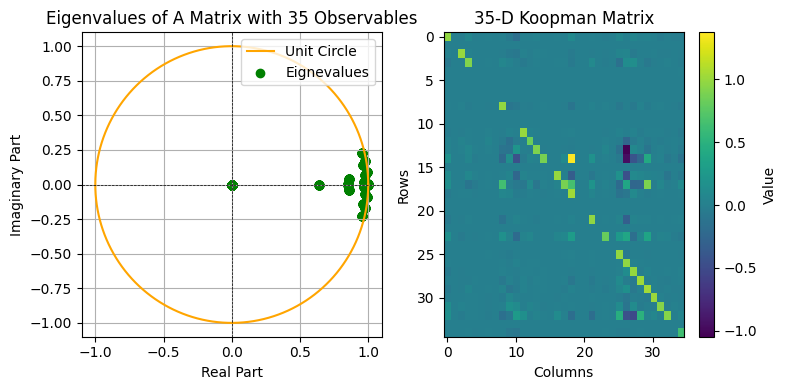

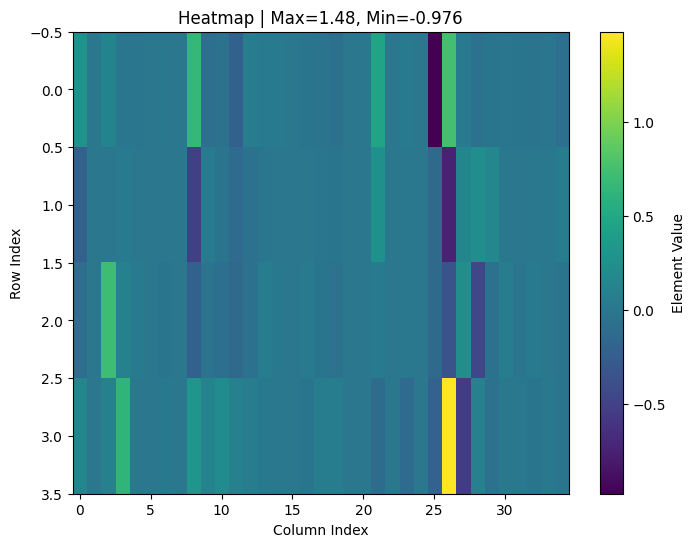

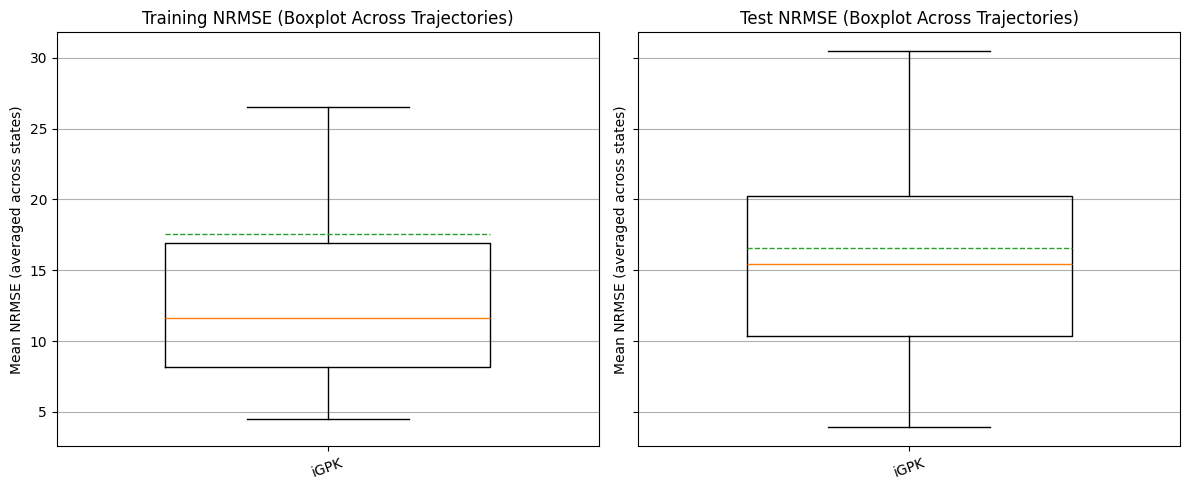

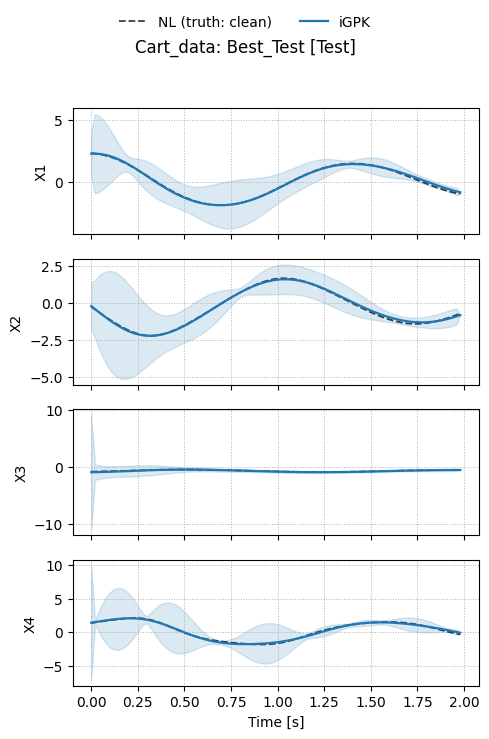

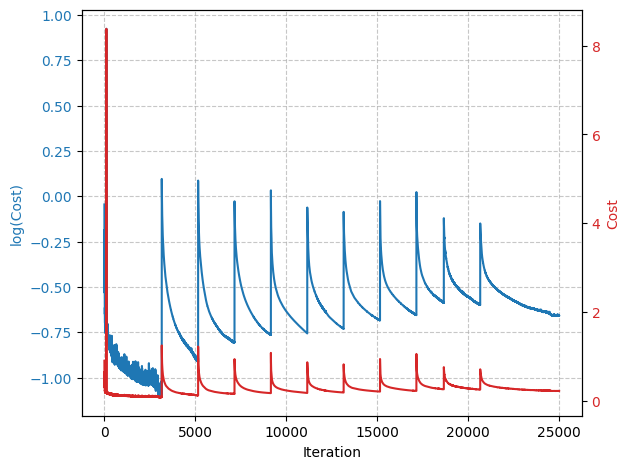

In [58]:
if True:    # Visualize iGPK Results
    print(f'Lifted Model Order:         {lifted_order:d}')
    print(f'Total Epochs executed:      {total_epochs:d}')
    print(f'Learning Time:              {t_iGPK:.2f} seconds')
    
    gpk.plot_eigen(A_igpk)
    gpk.MatViz(C_igpk, 'heat')
    TrainNRMSE = TrainNRMSE.clamp(max=1.5)
    TestNRMSE = TestNRMSE.clamp(max=1.5)
    gpk.plot_NRMSE_metrics([TrainNRMSE*100], [TestNRMSE*100], ['iGPK'])

    # 6) indices + timebase
    idx_trainMIN = torch.argmin(TrainNRMSE.mean(dim=1))
    idx_testMIN = torch.argmin(TestNRMSE.mean(dim=1))
    idx_testMAX = torch.argmax(TestNRMSE.mean(dim=1))
    time_arr = torch.arange(0., ts * (SimData.shape[2] - 1), ts)
    print(f'Median Train NMRSE: {100*TrainNRMSE.mean(dim=1).median():.2f}%')
    print(f'Mean Train NMRSE:   {100*TrainNRMSE.mean(dim=1).mean():.2f}%')
    print(f'Median Test NMRSE:  {100*TestNRMSE.mean(dim=1).median():.2f}%')
    print(f'Mean Test NMRSE:    {100*TestNRMSE.mean(dim=1).mean():.2f}%')

    # 7) pack models for overlay plot
    models = [
        {"name": "iGPK", "train": {"Xhat": XhatTrain, "Xcvhat": XcvhatTrain},
            "test": {"Xhat": XhatTest, "Xcvhat": XcvhatTest}}
    ]

    # a) 3 trajectory overlays
    for (which, idx, split, sim_offset, suffix) in [
        ("best-test",  idx_testMIN,  "test",  nTrain,    "Best_Test"),
    ]:
        gpk.compare_model_predictions(
            time=time_arr, models=models, SimData=SimData, idx=idx, N=(
                SimData.shape[2]-1),
            system_name=system_name, title_suffix=suffix, split=split, sim_offset=sim_offset,
            compare_to="SimData_clean", SimData_clean=SimData_clean, sigma=1.0
        )

    cost_history = results["history"].get("cost", None)
    # Plot Cost History
    fig, ax1 = plt.subplots()
    color = 'tab:blue'
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('log(Cost)', color=color)
    ax1.plot(torch.log10(torch.abs(cost_history)), color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Cost', color=color)
    ax2.plot(cost_history, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    fig.tight_layout()

    # plt.plot(results["history"]['mean_grad'])

    ### NLPD Calulation
    GT_test = SimData[nTrain:nTrain+nTest, :, :N-1]  # (nTest, n, N)

    nlpd_traj_test_igpk = _nlpd_per_traj(
        XhatTest[:, :, :N-1],       XcvhatTest[:, :, :, :N-1],       GT_test).detach().cpu()

    # Print summary
    m, s = _ms(nlpd_traj_test_igpk)
    print(f"Test  NLPD iGPK:     mean={m:.4f}, std={s:.4f}")

    plt.show()

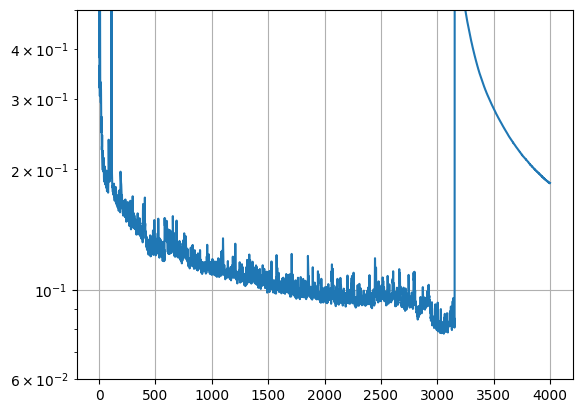

In [55]:
plt.plot(cost_history[:4000])
plt.yscale('log')
plt.ylim(0.06, 0.5)
plt.grid()

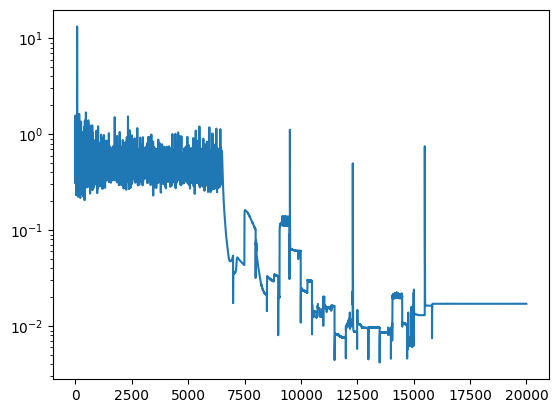

In [39]:
plt.plot(results["history"]['mean_grad'])
plt.yscale('log')
plt.show()

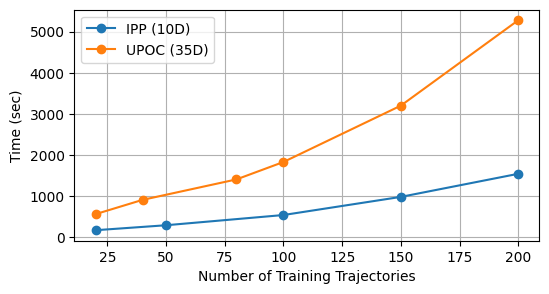

In [11]:
ipp_x = [20, 50, 100, 150, 200]
ipp_time = [175.85, 296.78, 545.113, 985.73, 1546.884]

upoc_x = [20, 40, 80, 100, 150, 200]
upoc_time = [566.34, 913.136, 1410.616, 1833.535, 3203.054, 5278.45]

plt.figure(figsize=(6,3))
plt.plot(ipp_x, ipp_time, marker='o', label='IPP (10D)')
plt.plot(upoc_x, upoc_time, marker='o', label='UPOC (35D)')
plt.xlabel('Number of Training Trajectories')
plt.ylabel('Time (sec)')
plt.legend()
plt.grid()
plt.show()

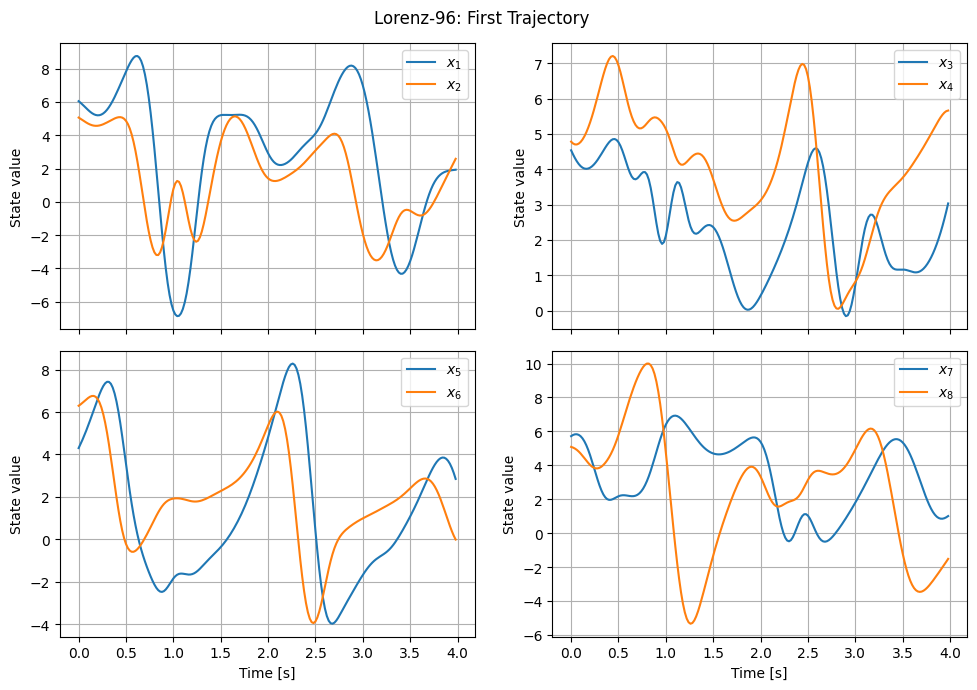

In [ ]:
import torch
import matplotlib.pyplot as plt
import GPKoopman as gpk

# -----------------------------
# Config
# -----------------------------
SYSTEM_NAME = "Lorenz96_8D"
nx = 8
num_trajectories = 200
num_steps = 200
ts = 0.02
F = 5.0

torch.manual_seed(100)

# -----------------------------
# Generate initial conditions
# -----------------------------
ICset = 5.0 + 0.5 * torch.randn(num_trajectories, nx, dtype=torch.float64)

# -----------------------------
# Simulate trajectories
# SimData shape: (num_trajectories, nx, num_steps)
# -----------------------------
SimData = torch.zeros((num_trajectories, nx, num_steps), dtype=torch.float64)

for j in range(num_trajectories):
    SimData[j] = gpk.sim_RK4(
        gpk.f_Lorenz96,
        ICset[j],
        ts,
        num_steps,
        params=torch.tensor([F], dtype=torch.float64),
    )

# -----------------------------
# Save dataset
# -----------------------------
torch.save(
    {
        "trajectories": SimData,
        "sample_time": ts,
        "num_trajectories": num_trajectories,
        "num_steps": num_steps - 1,
        "system": SYSTEM_NAME,
        "F": F,
    },
    f"Data/DataAuto_{SYSTEM_NAME}.pt",
)

# -----------------------------
# Plot first trajectory
# 2-by-2 subplot, 2 states per subplot
# -----------------------------
time = torch.arange(num_steps) * ts

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

state_pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]

for ax, (i, k) in zip(axes, state_pairs):
    ax.plot(time, SimData[0, i], label=f"$x_{i+1}$")
    ax.plot(time, SimData[0, k], label=f"$x_{k+1}$")
    ax.set_ylabel("State value")
    ax.grid(True)
    ax.legend()

axes[-2].set_xlabel("Time [s]")
axes[-1].set_xlabel("Time [s]")

fig.suptitle("Lorenz-96: First Trajectory")
fig.tight_layout()
plt.show()